In [1]:
from hossam import load_data
from helpers import *
from IPython.display import display, Markdown

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.33


In [2]:
origin = load_data("titanic_qtcheck")
num_desc = load_data("titanic_numerical_summary")
cat_desc = load_data("titanic_categorical_summary")

📚 타이타닉호 침몰 데이터셋의 품질점검 완료 버전 (출처: 자체 작업)

    field       description
--  ----------  -----------------------------------------------------
 0  Survived    생존 여부 (종속변수,범주형, 1=생존, 0=사망)
 1  Pclass      티켓 등급(범주형, 1=1등석, 2=2등석, 3=3등석)
 2  Fare        요금
 3  Age         나이
 4  Embarked    승선 항구(범주형, C=쉘버그, Q=퀸스타운, S=사우샘프턴)
 5  HasCabin    객실 보유 여부(범주형, True=보유, False=미보유)
 6  FamilySize  가족 규모
 7  Title       신분(범주형, Mr, Miss, Mrs, Master, Officer)

📚 타이타닉호 침몰 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 타이타닉호 침몰 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 1306 entries, 0 to 1305
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    1306 non-null   category
 1   Pclass      1306 non-null   category
 2   Age         1306 non-null   float64 
 3   Fare        1306 non-null   float64 
 4   Embarked    1306 non-null   category
 5   HasCabin    1306 non-null   category
 6   FamilySize  1306 non-null   int64   
 7   Title       1306 non-null   category
dtypes: category(5), float64(2), int64(1)
memory usage: 37.2 KB


In [4]:
column_means = {
    "Survived":     "생존 여부 (0=사망, 1=생존)",
    "Pclass":       "객실 등급 (1=1등급, 2=2등급, 3=3등급)",
    "Age":          "나이",
    "Fare":         "요금",
    "Embarked":     "탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)",
    "HasCabin":     "선실 존재 여부 (True=선실 있음, False=선실 없음)",
    "FamilySize":   "동승 가족 수 (SibSp + Parch + 본인)",
    "Title":        "이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)"
}

In [5]:
target = "Survived"             # 종속변수 이름
target_is_continuous = False    # 종속변수 연속형 여부

# 분석 대상에서 제외할 변수
exclude_cols = []

nominal_cols = my_qtcheck.get_categorical_column_names(df)  # 범주형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)   # 연속형 변수

if target_is_continuous:                    # 종속변수가 연속형 변수라면?
    continuous_cols.remove(target)          # 연속형 변수 이름에서 종속변수 항목 제거
else:                                       # 종속변수가 범주형 변수라면?
    nominal_cols.remove(target)             # 범주형 변수 이름에서 종속변수 항목 제거

# 제외 대상으로 지정한 변수를 각 목록에서 제거한다.
# -> 범주형에도 적용하므로 제외 대상이 범주형인 경우에도 그대로 동작한다.
continuous_cols = [c for c in continuous_cols if c not in exclude_cols]
nominal_cols = [c for c in nominal_cols if c not in exclude_cols]

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "범주형"))
print("범주형   :", nominal_cols)
print("연속형   :", continuous_cols)
print("제외     :", exclude_cols)

종속변수 : Survived
종속변수 유형: 범주형
범주형   : ['Pclass', 'Embarked', 'HasCabin', 'Title']
연속형   : ['Age', 'Fare', 'FamilySize']
제외     : []


---

# 02.단변량 분석

### 1.명목형 종속변수에 대한 단변량 분석

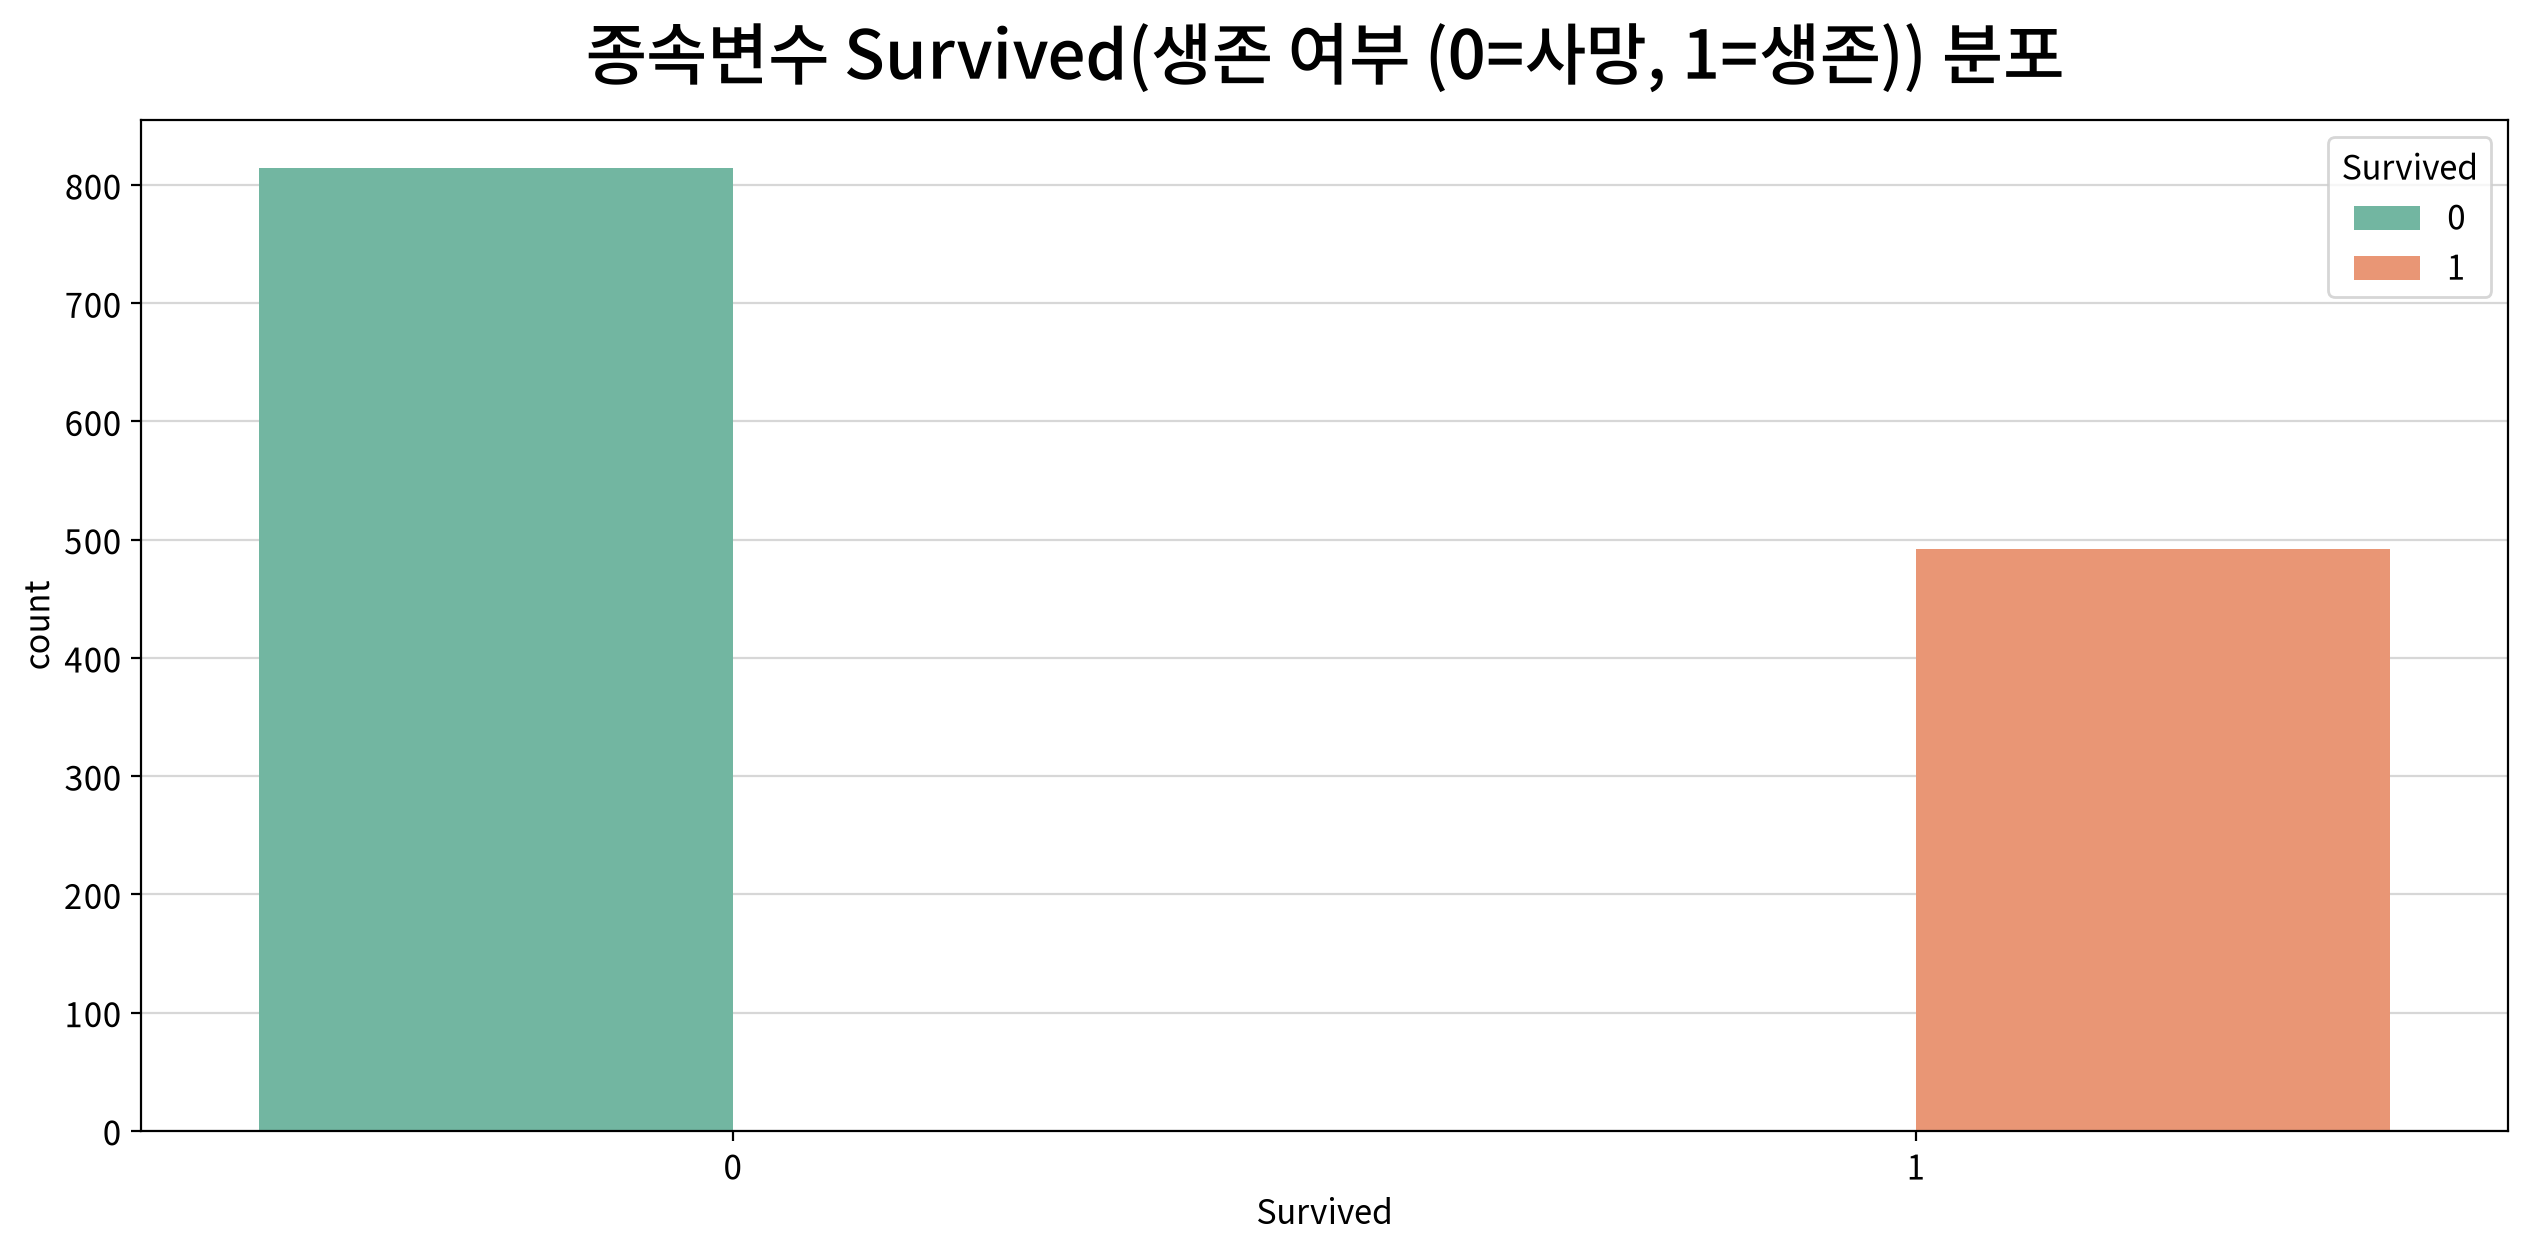

,count,unique,top,freq
Survived,1306,2,0,814


,빈도,비율
Survived,,
0,814,0.623
1,492,0.377


In [6]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette="Set2",
                  title=f"종속변수 {target}({column_means[target]}) 분포")

# 명목형 기술통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq = df[target].value_counts().rename("빈도").to_frame()
freq["비율"] = df[target].value_counts(normalize=True)
display(freq)

### 💡 인사이트

| 점검 항목 | Survived 관찰값 |
| :--- | :--- |
| **범주 수** | 2 (0=사망 / 1=생존) → **이분형** 이므로 로지스틱 회귀 적용 가능 |
| **최빈 범주** | 사망 814건 (62.3%) |
| **최소 범주** | 생존 492건 (37.7%) |
| **균형 여부** | **약한 불균형 (62 : 38)** |

* **정확도의 바닥값(baseline)은 62.3% 다.** 모두 "사망"이라고만 답하는 게으른 모형도 62.3%를 맞힌다.
  * 즉 정확도 70%짜리 모형은 **좋은 모형이 아니다.** 바닥값보다 8%p 나은 것에 불과하다.
  * Apple Quality의 바닥값이 50.1%였던 것과 비교해야 한다. **같은 정확도라도 데이터마다 의미가 다르다.**
* **62 : 38 정도의 불균형은 심각한 수준은 아니라 별도의 리샘플링 없이 진행하지만, 정확도 하나만 보지 말고 재현율·정밀도·AUC를 함께 확인해야 한다.**

### 2. 명목형 독립변수에 대한 단변량 분석

* **명목형 독립변수도 범주별 빈도의 쏠림을 확인한다.** 한 범주에 관측치가 지나치게 적으면 그 더미변수의 계수가 불안정해지기 때문이다.

### ❓ Pclass(객실 등급 (1=1등급, 2=2등급, 3=3등급)) 분포

Pclass,3,1,2
빈도,708.000,321.000,277.000
비율,0.542,0.246,0.212


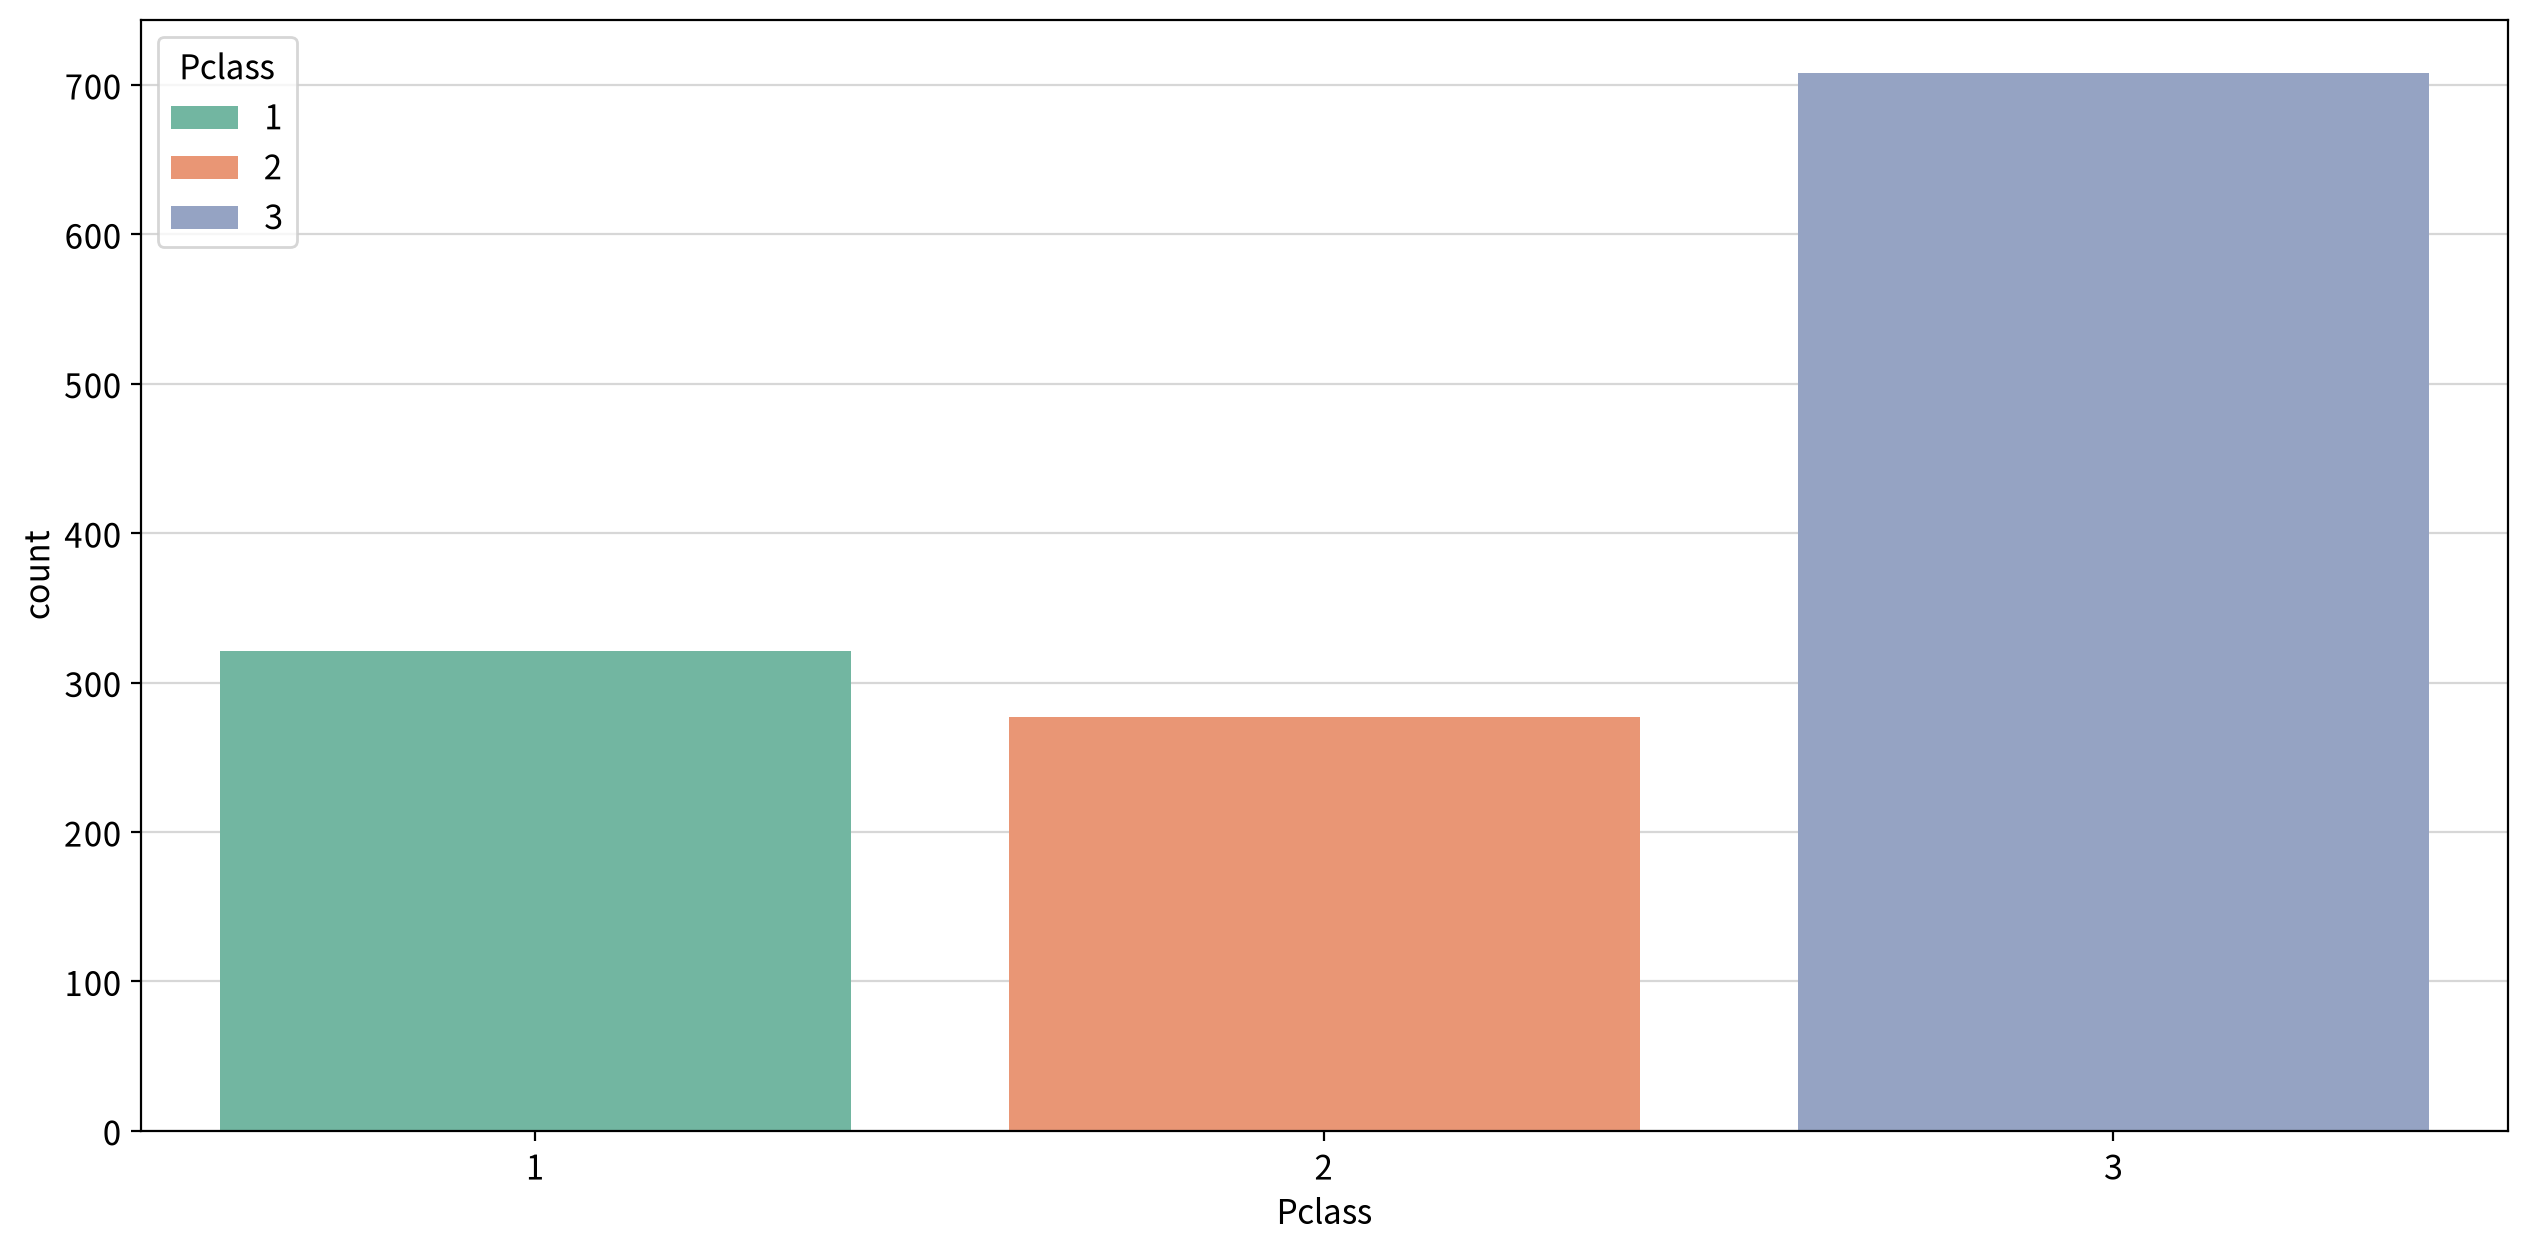

### ❓ Embarked(탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)) 분포

Embarked,S,C,Q
빈도,913.000,270.000,123.000
비율,0.699,0.207,0.094


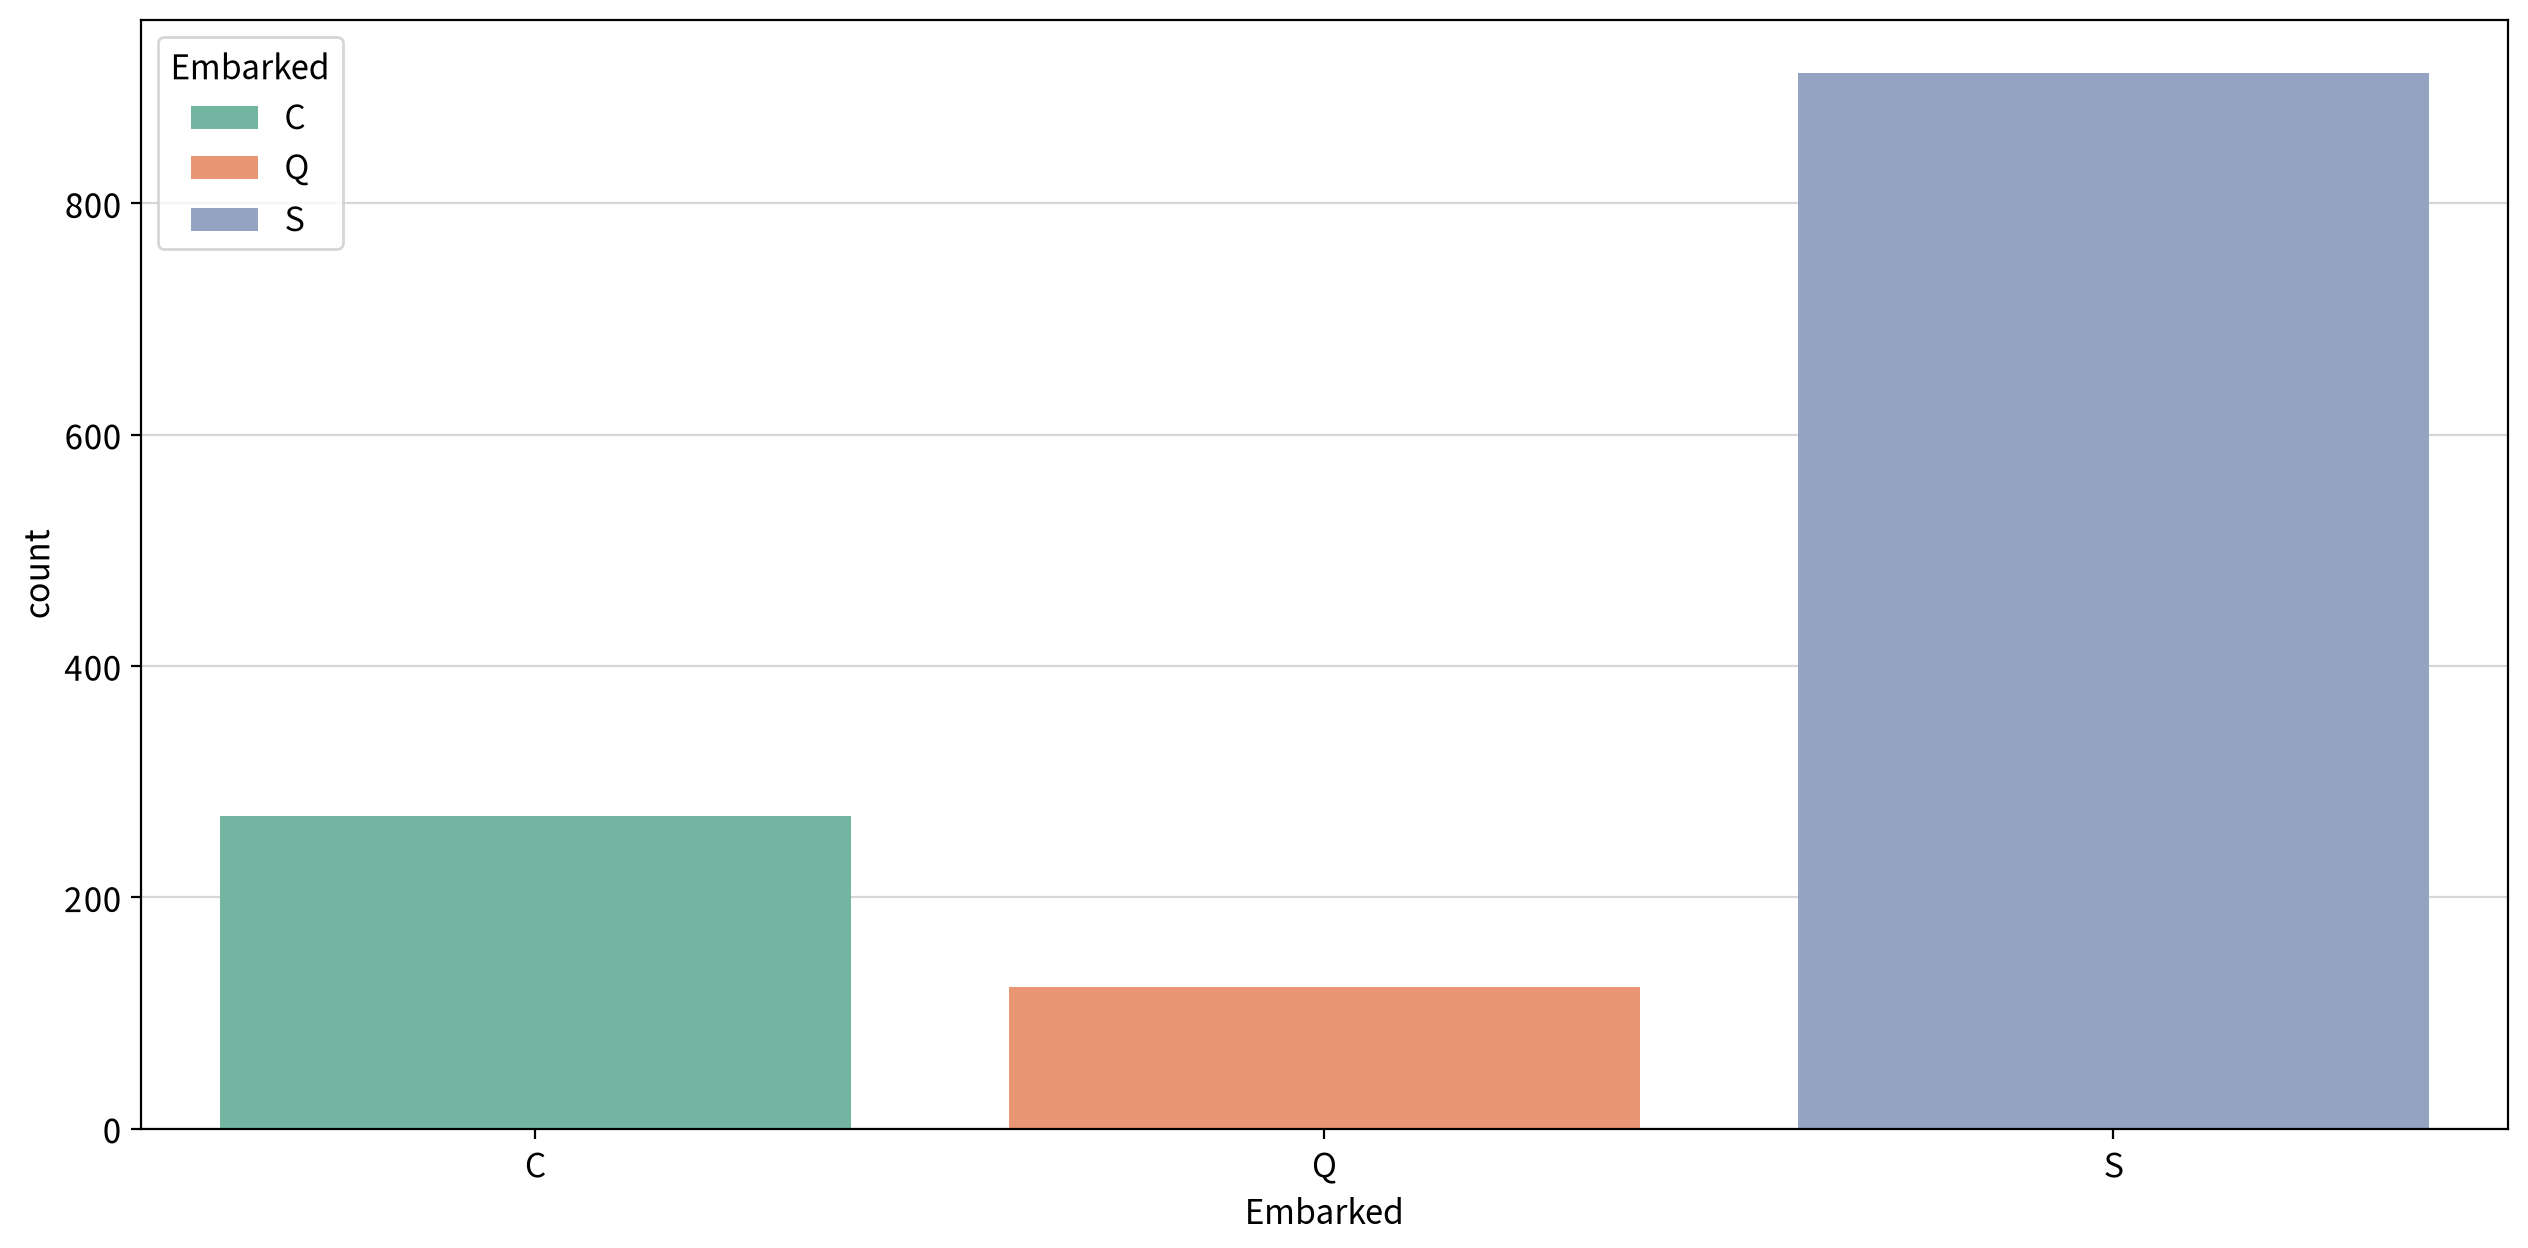

### ❓ HasCabin(선실 존재 여부 (True=선실 있음, False=선실 없음)) 분포

HasCabin,False,True
빈도,1013.000,293.000
비율,0.776,0.224


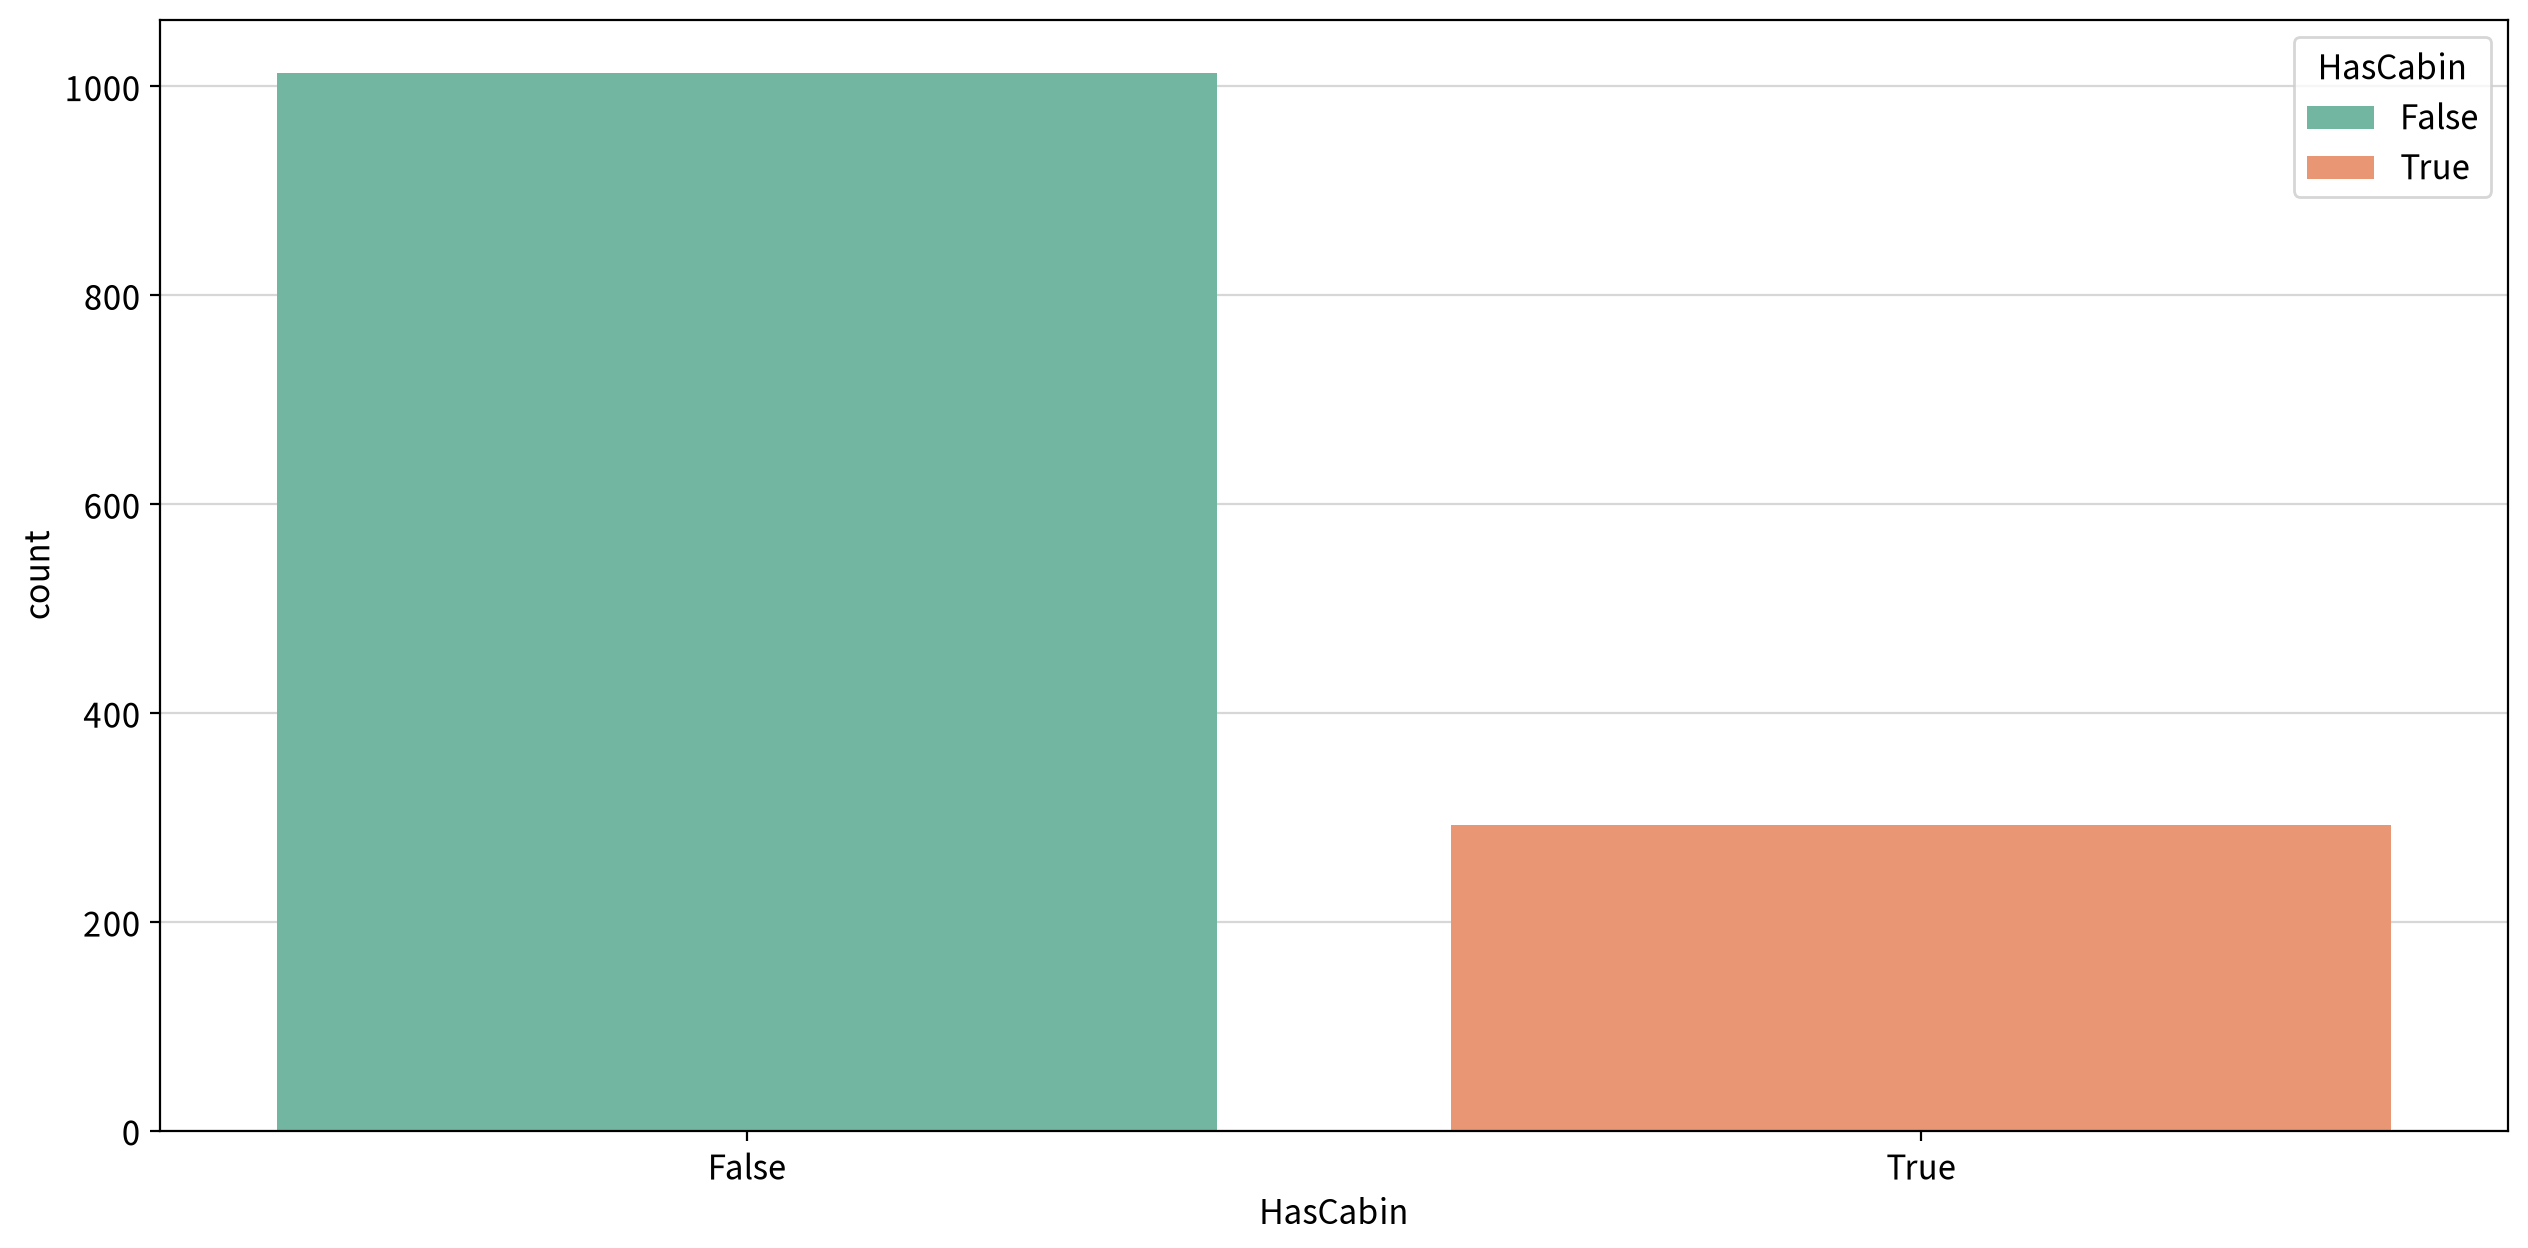

### ❓ Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) 분포

Title,Mr,Miss,Mrs,Master,Officer
빈도,759.000,263.000,200.000,61.000,23.000
비율,0.581,0.201,0.153,0.047,0.018


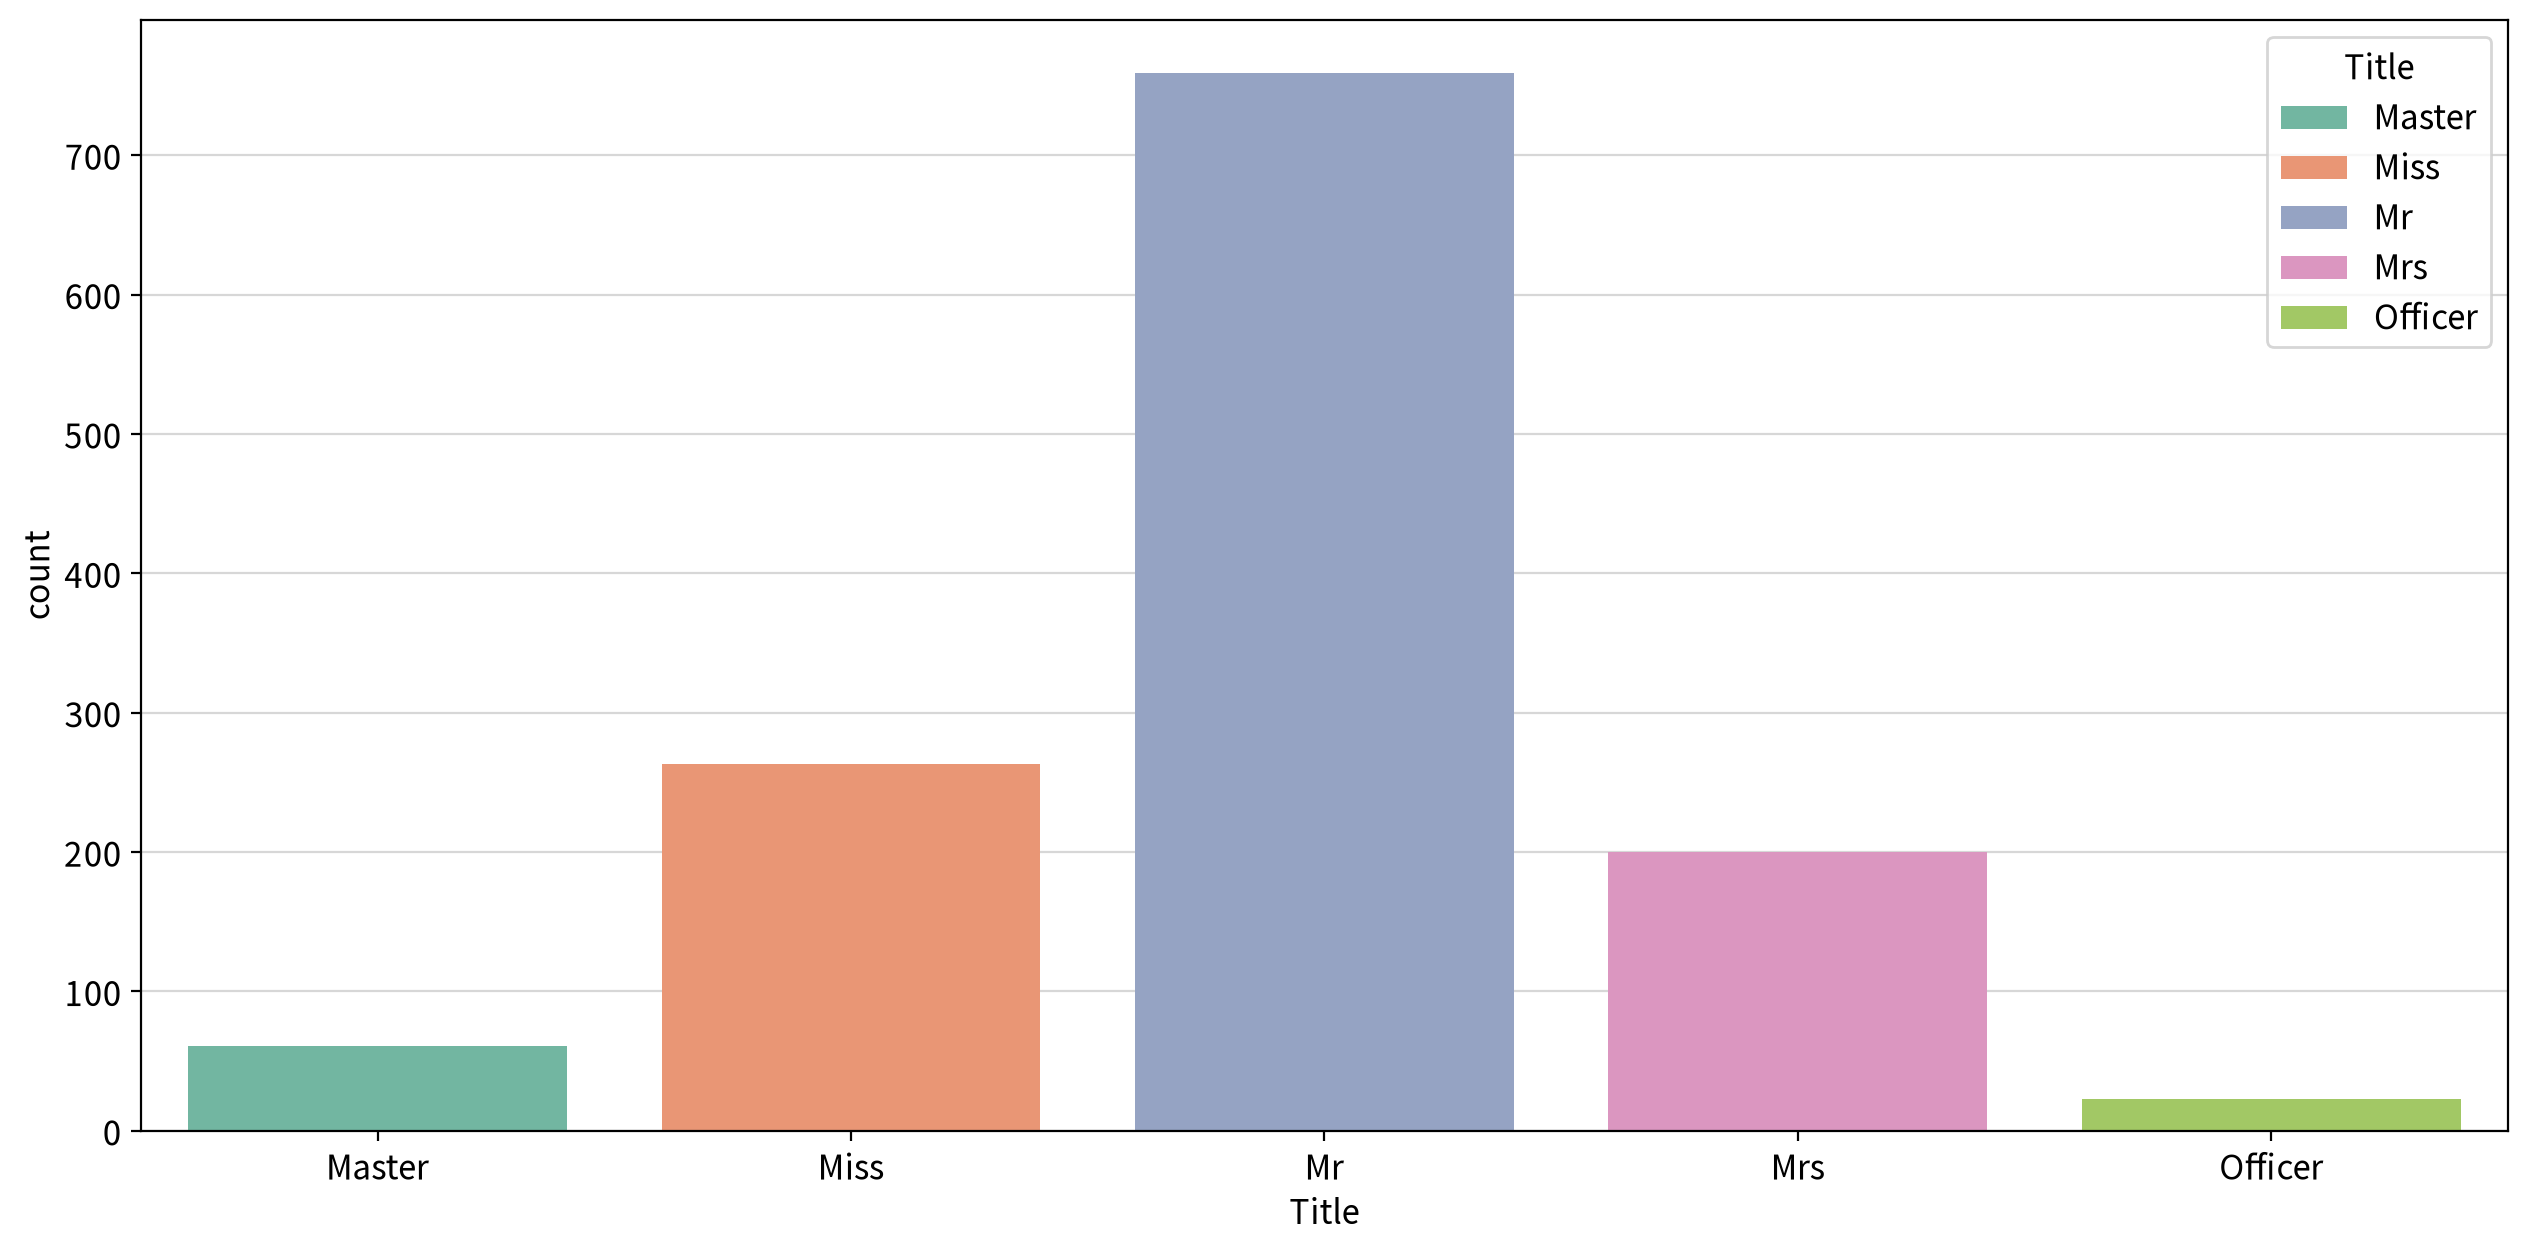

In [7]:
for n in nominal_cols:
    display(Markdown(f"### ❓ {n}({column_means[n]}) 분포"))
    freq = df[n].value_counts().rename("빈도").to_frame()
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq.T)
    
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2",dodge=False)

### 3. 연속형 독립변수에 대한 단변량 분석

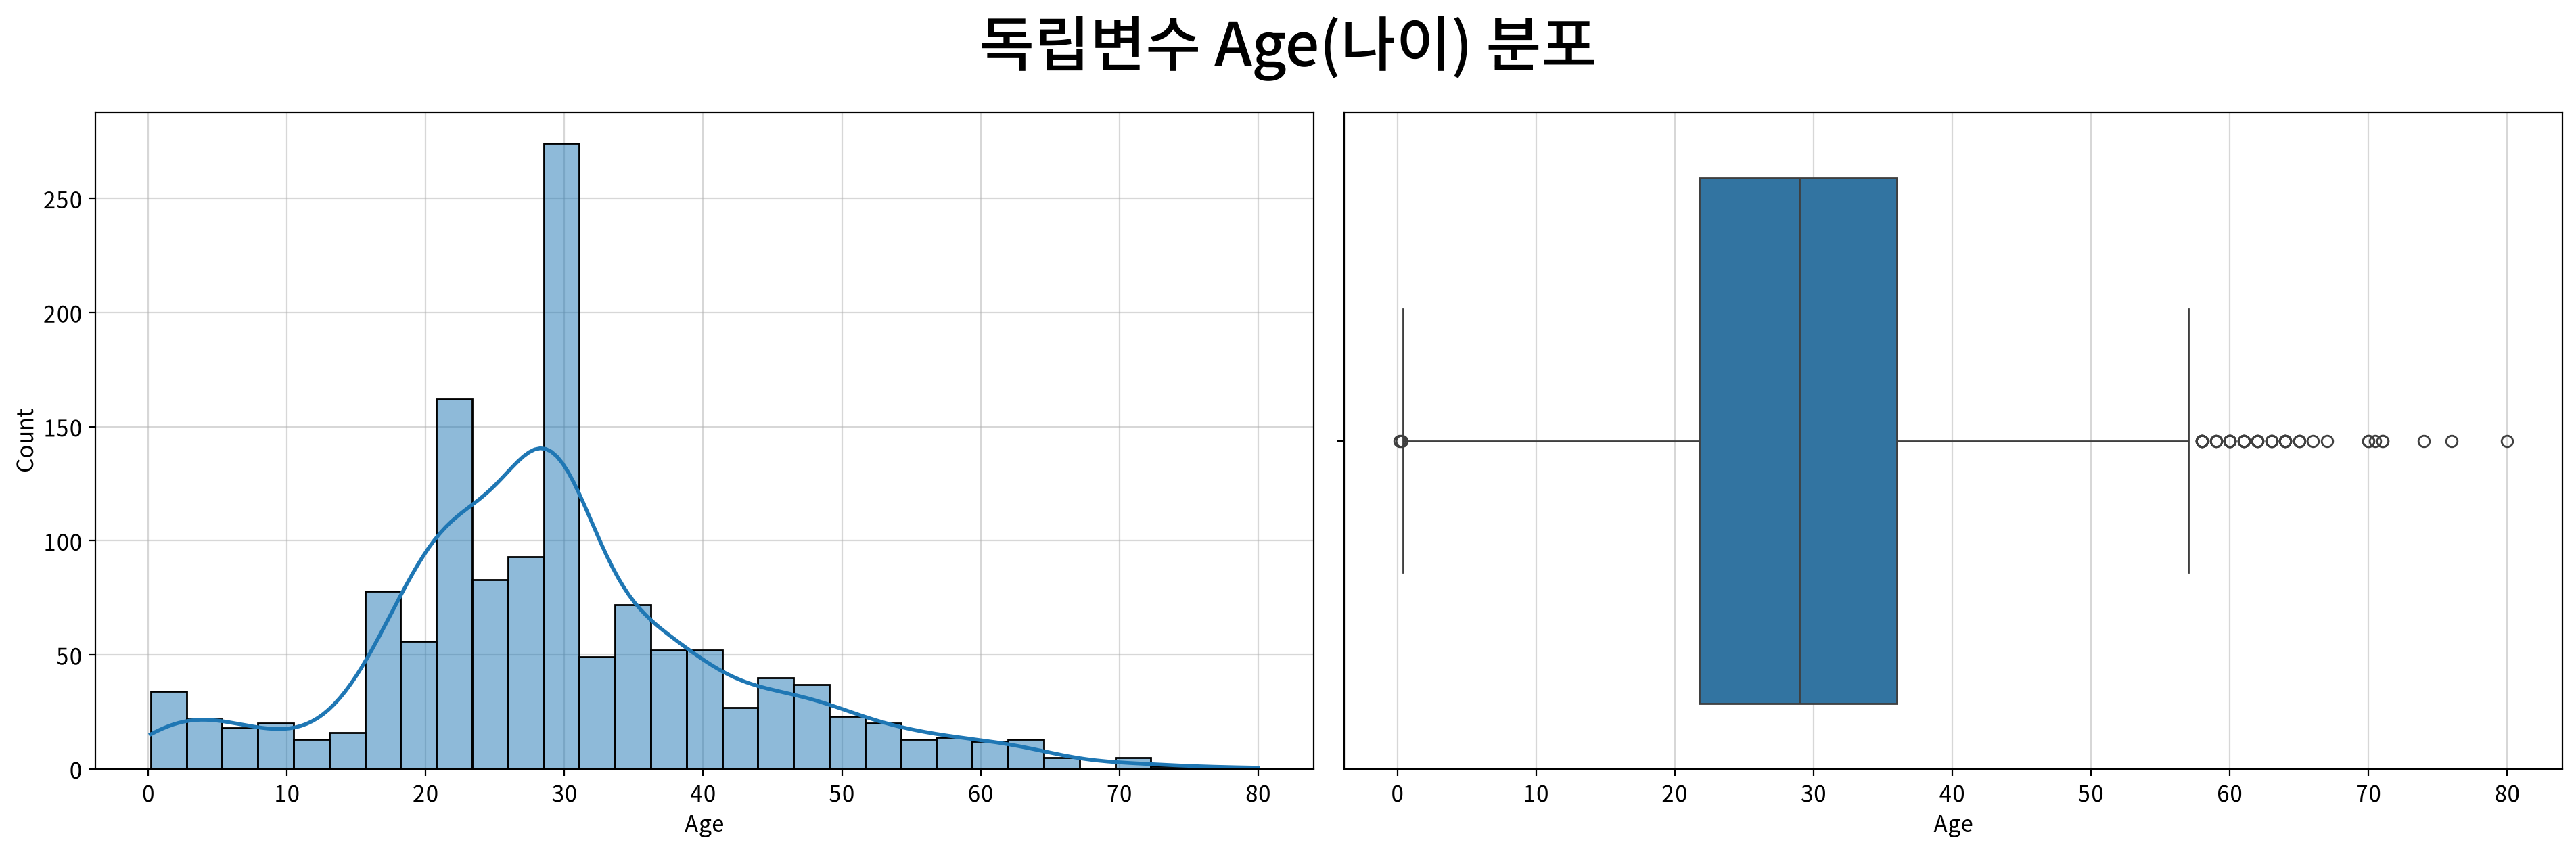

,Age
count,1306.000
mean,29.397
std,13.119
min,0.170
25%,21.748
50%,29.000
75%,36.000
max,80.000
rel_diff,0.014
rdiff_flag,similar


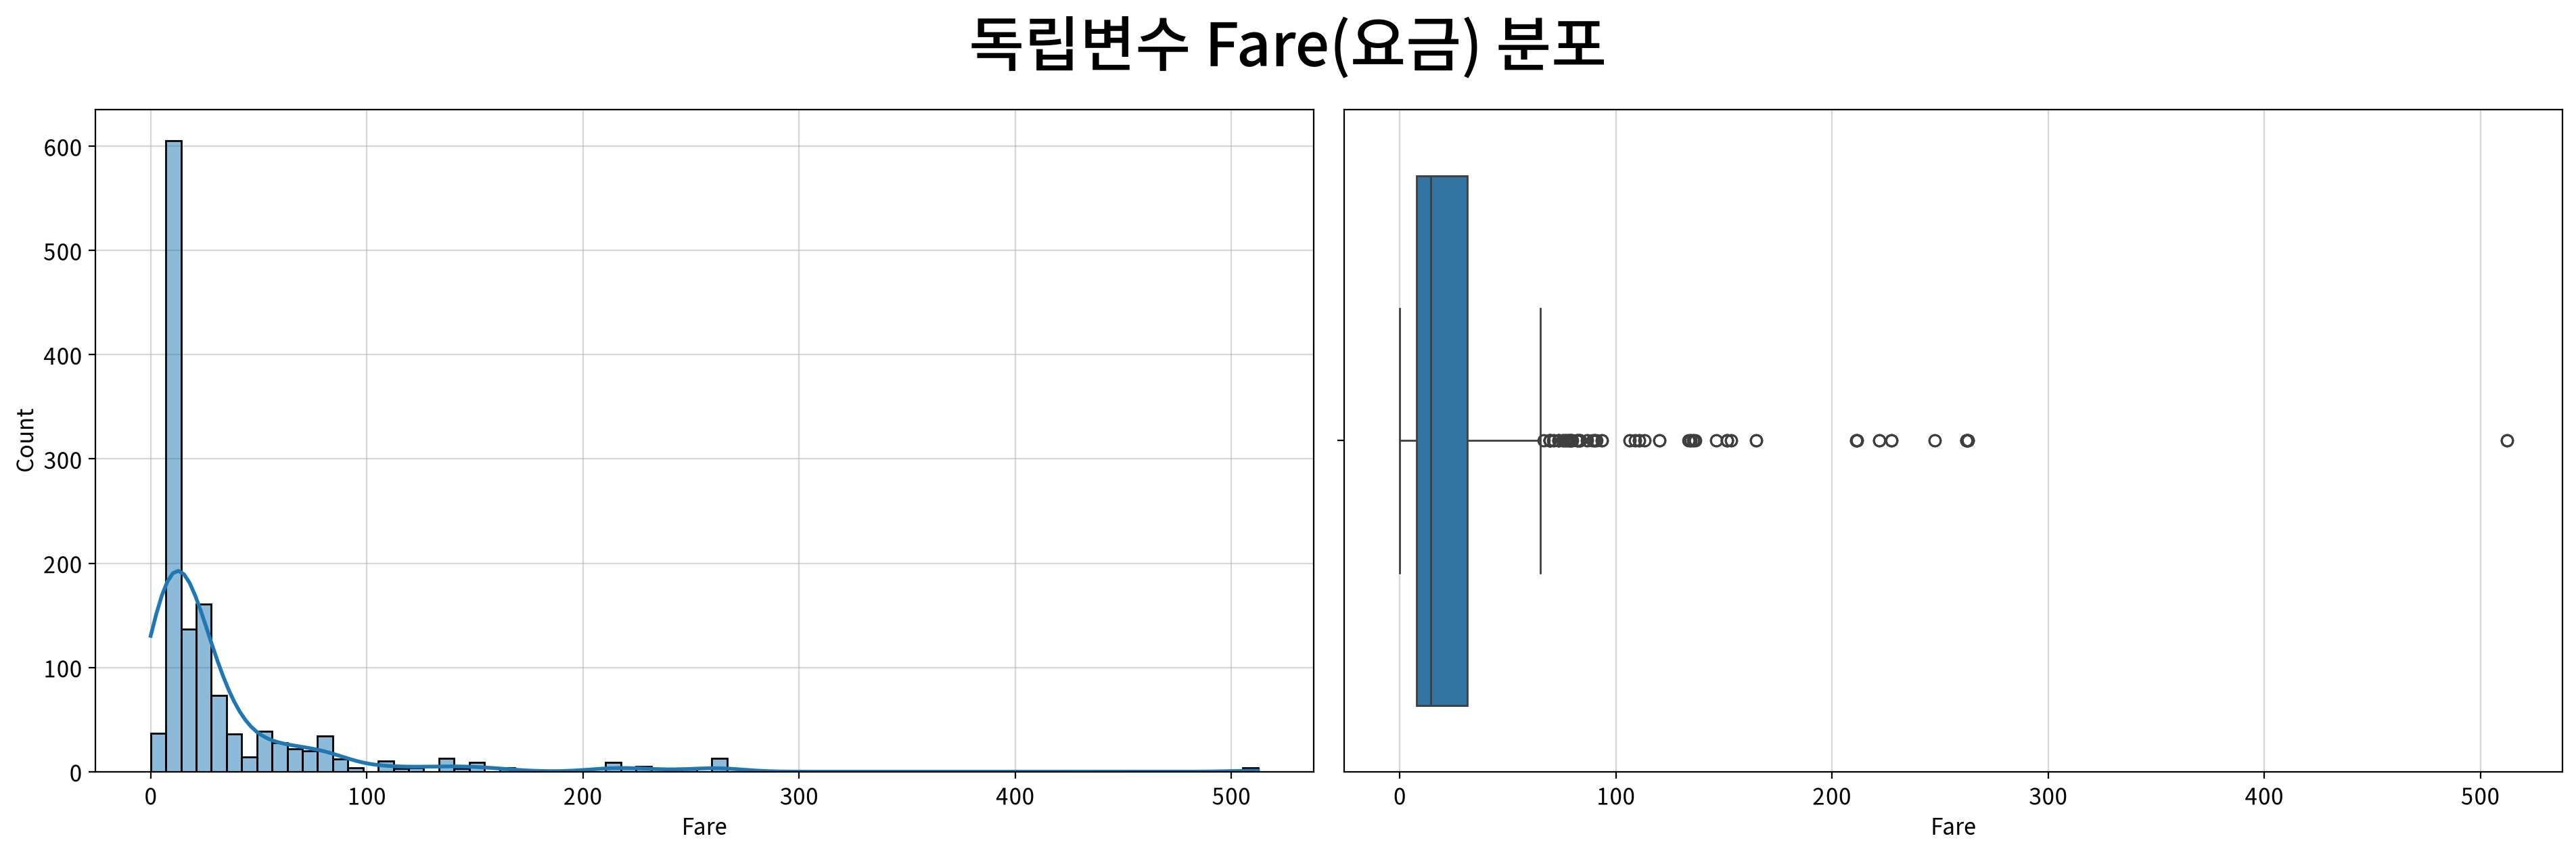

,Fare
count,1306.000
mean,33.224
std,51.766
min,0.000
25%,7.896
50%,14.454
75%,31.275
max,512.329
rel_diff,1.299
rdiff_flag,large_diff


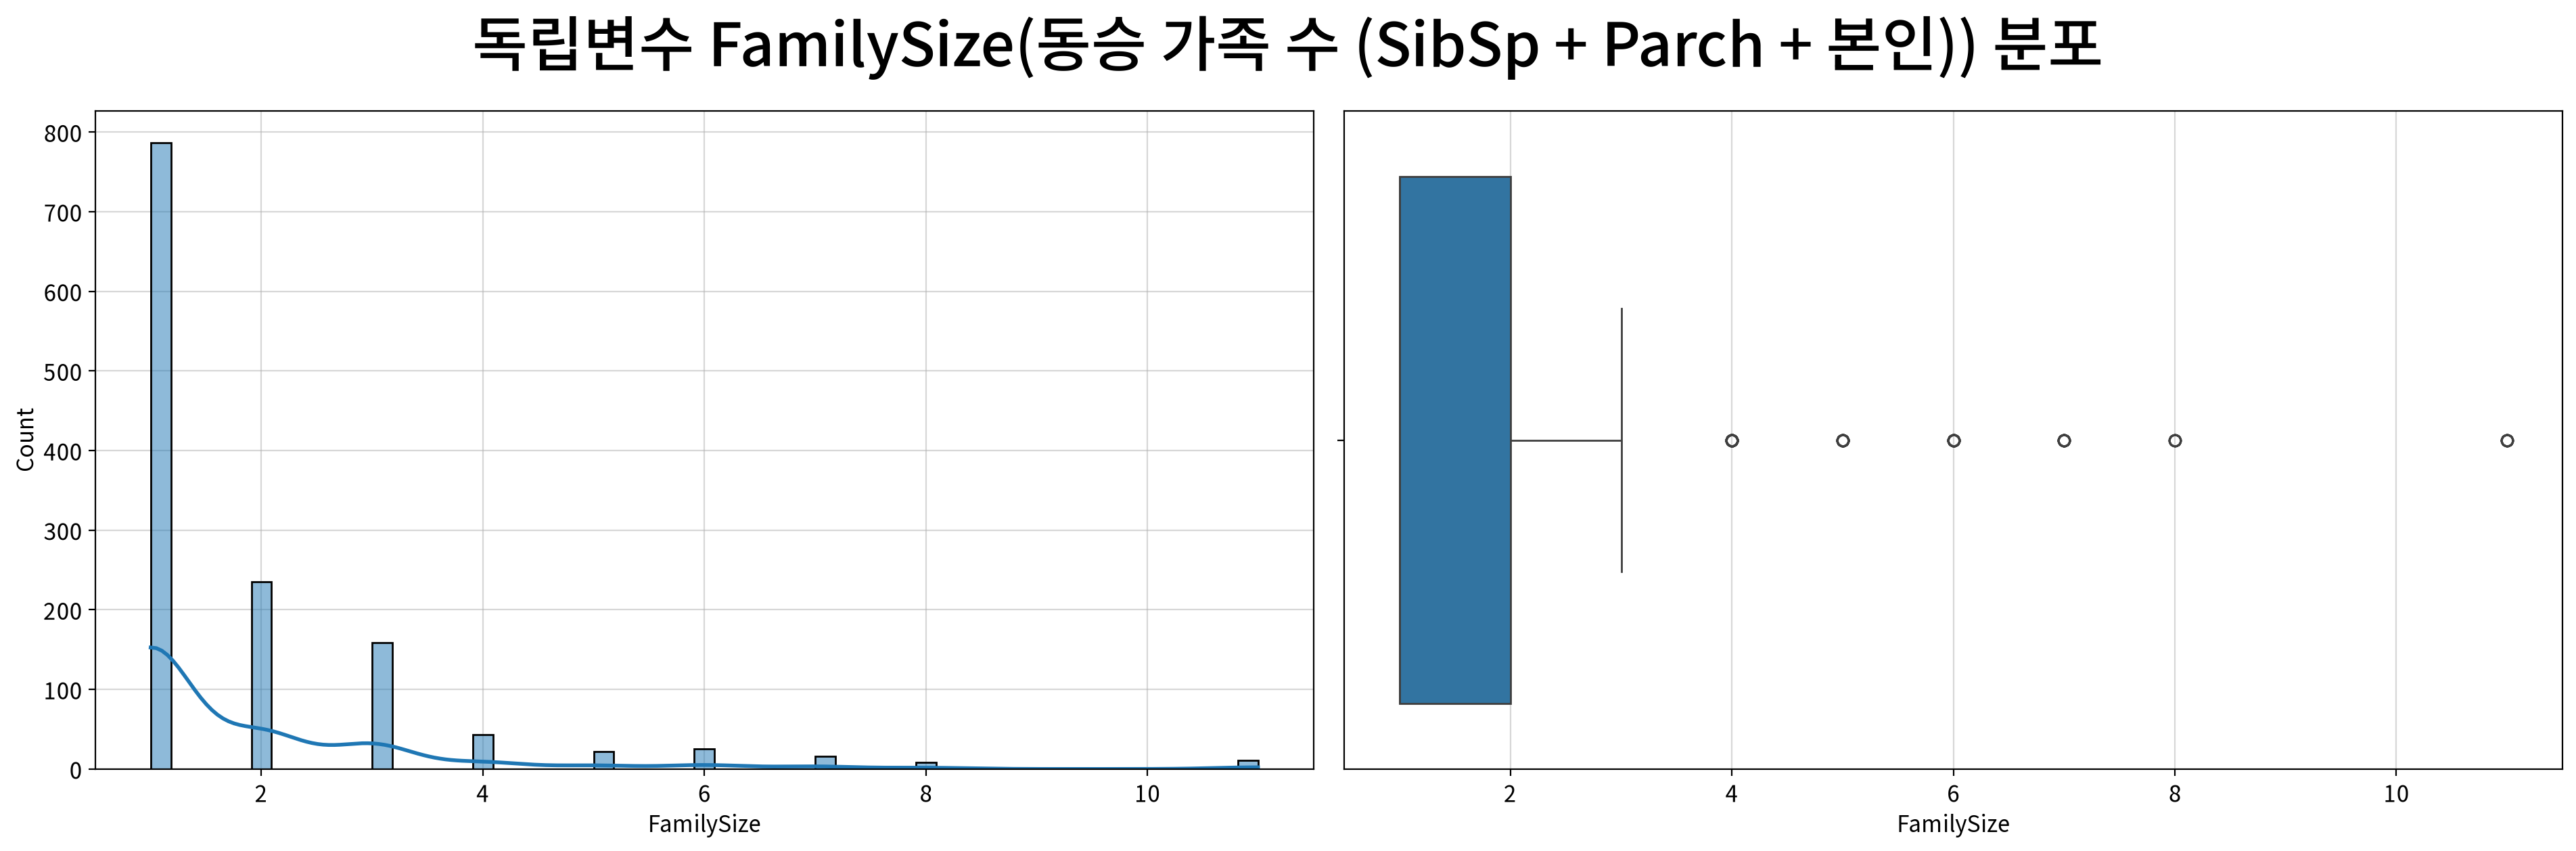

,FamilySize
count,1306.000
mean,1.886
std,1.585
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,11.000
rel_diff,0.886
rdiff_flag,large_diff


In [8]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                          title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

---

# 03. 이변량 분석

### 1. T-Test (x:연속형 독립변수 --> y: 2집단 명목형 종속변수)

#### 📊 Age(나이) → Survived

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.159e-01 U_stat=2.106e+05


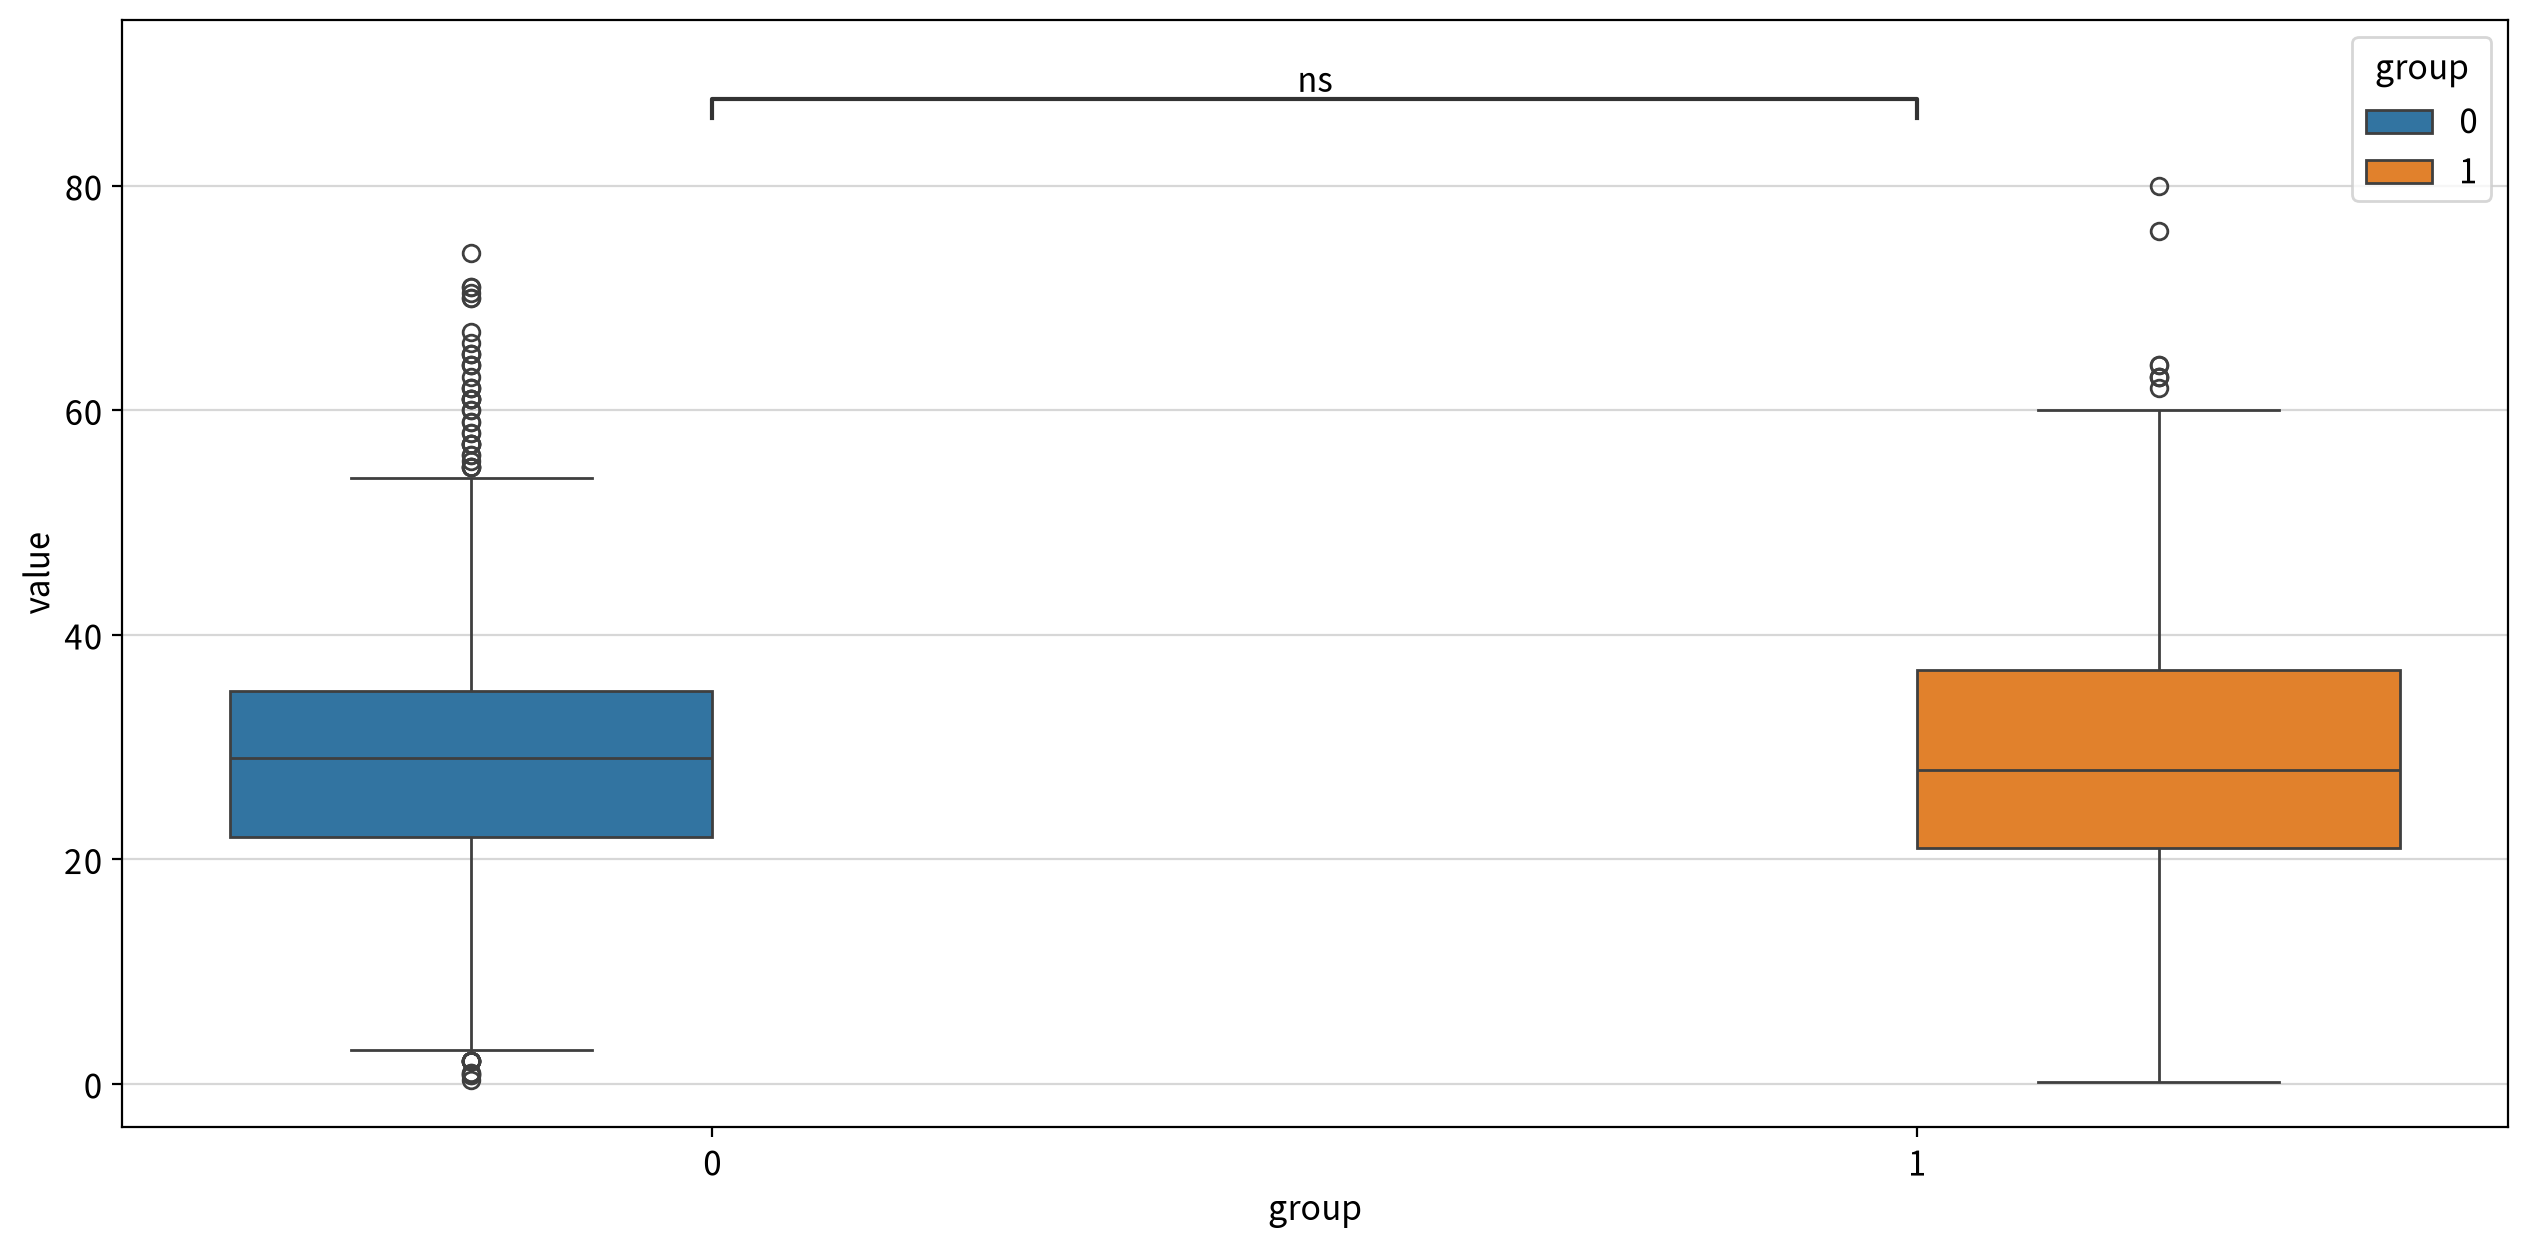

statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided   210604.500    0.116        False   0 = 1
                    less        210604.500    0.942        False  0 >= 1
                    greater     210604.500    0.058        False  0 <= 1

#### 📊 Fare(요금) → Survived

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:1.570e-24 U_stat=1.327e+05


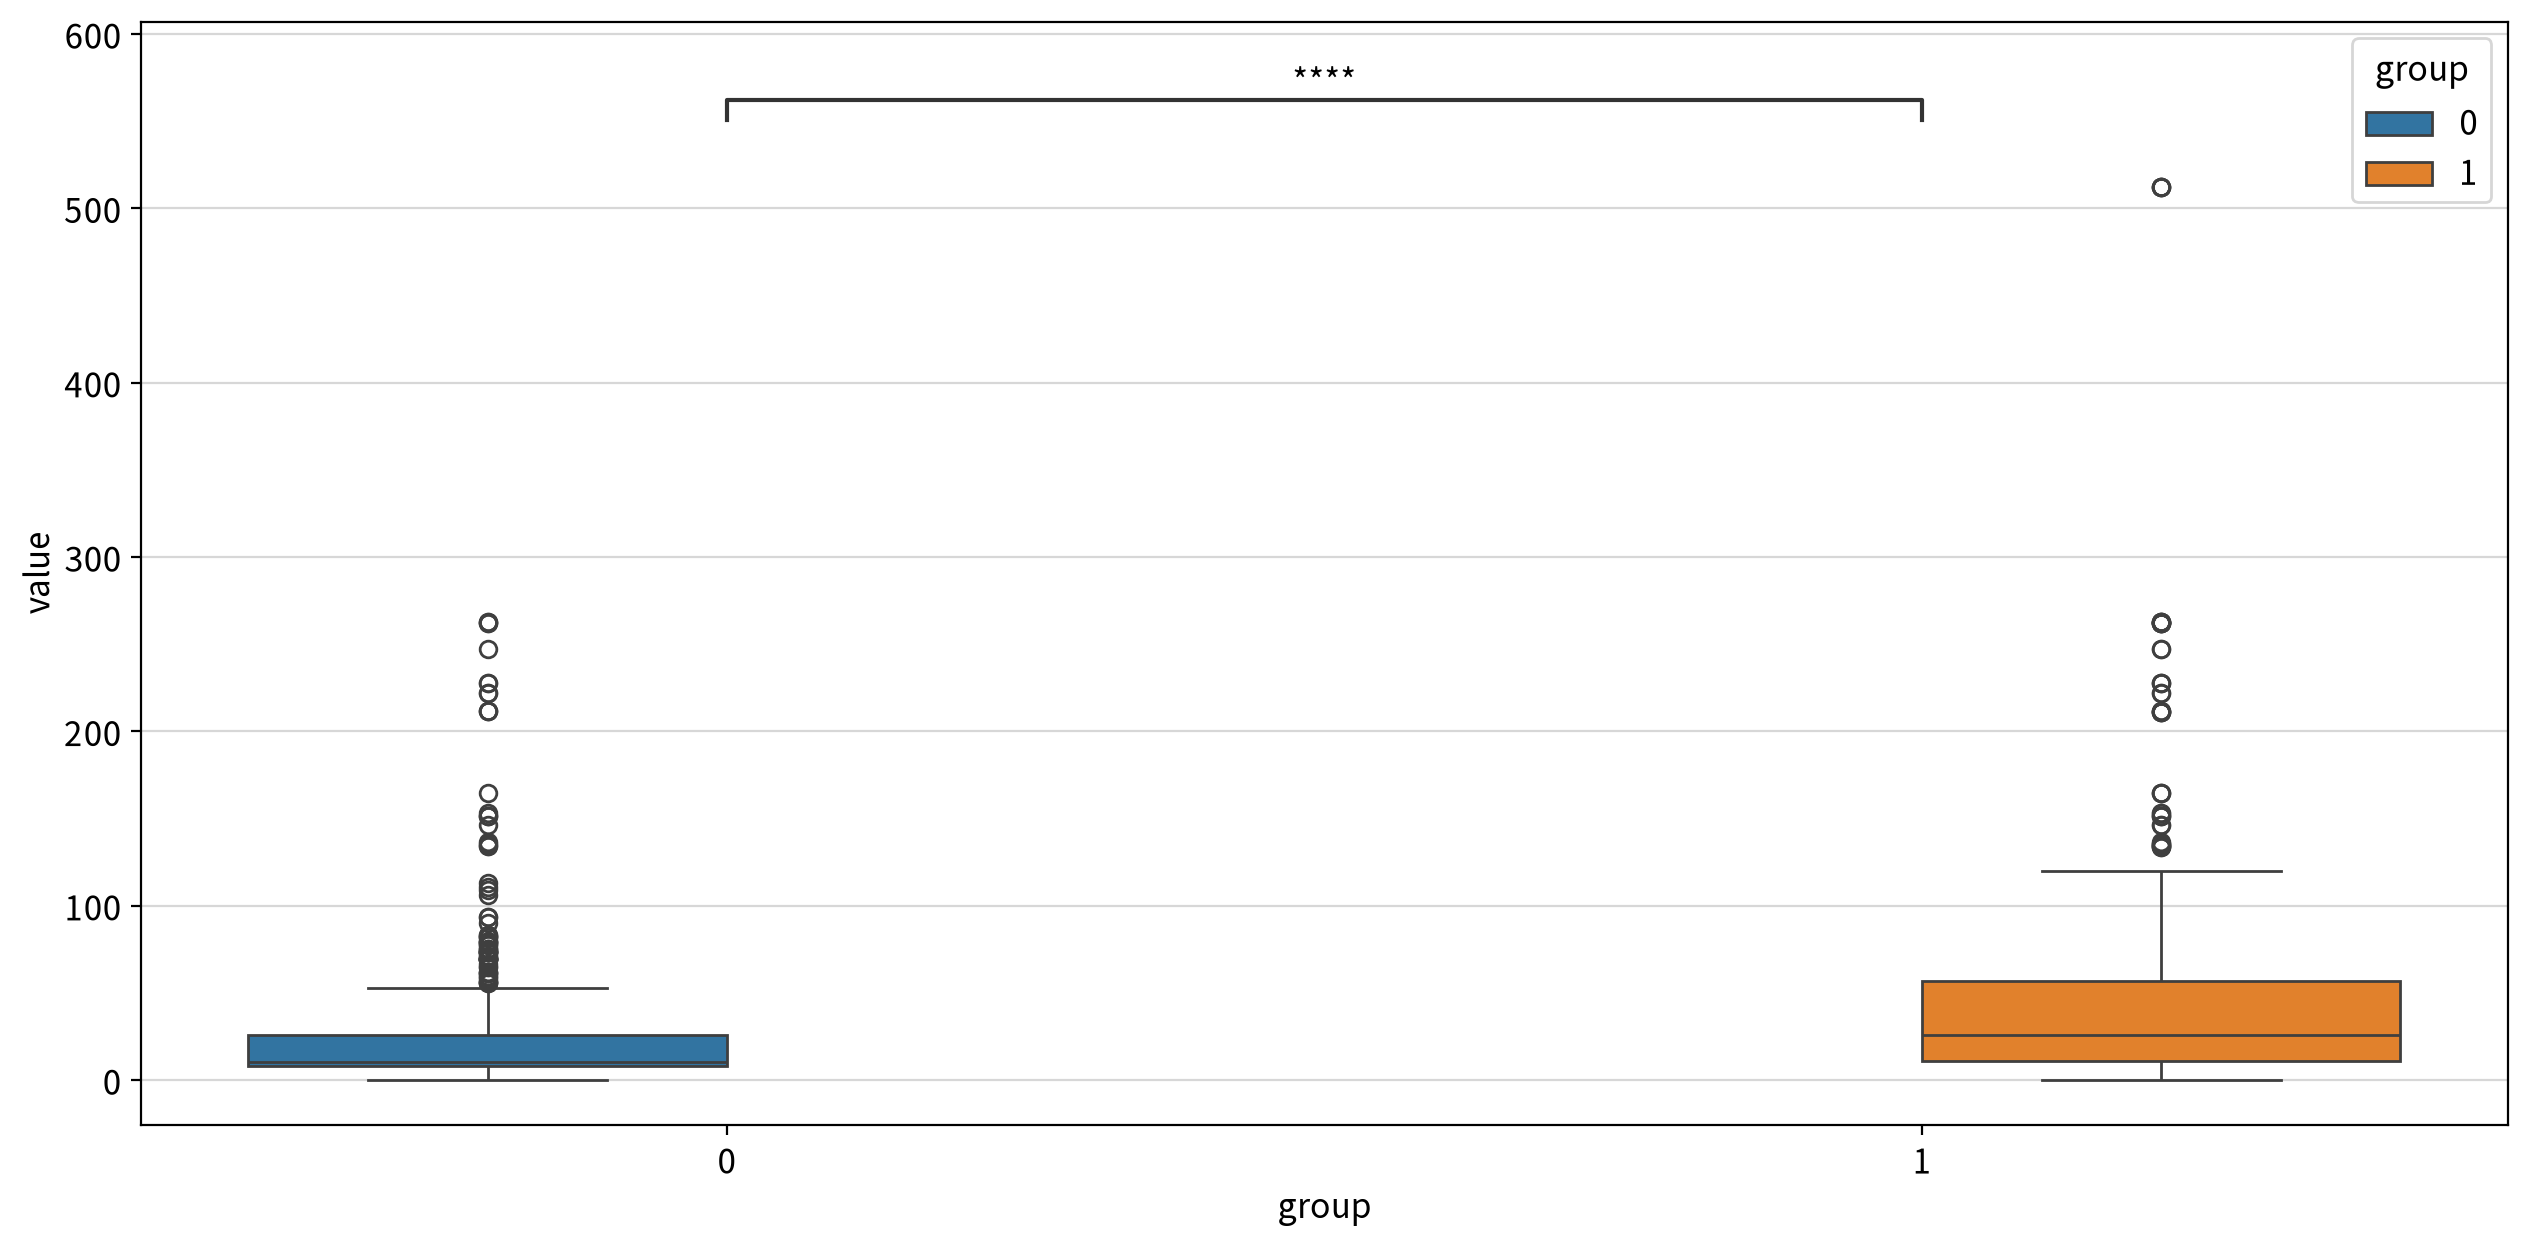

statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided   132743.000    0.000         True  0 != 1
                    less        132743.000    0.000         True   0 < 1
                    greater     132743.000    1.000        False  0 <= 1

#### 📊 FamilySize(동승 가족 수 (SibSp + Parch + 본인)) → Survived

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

0 vs. 1: Mann-Whitney-Wilcoxon test two-sided, P_val:5.986e-12 U_stat=1.603e+05


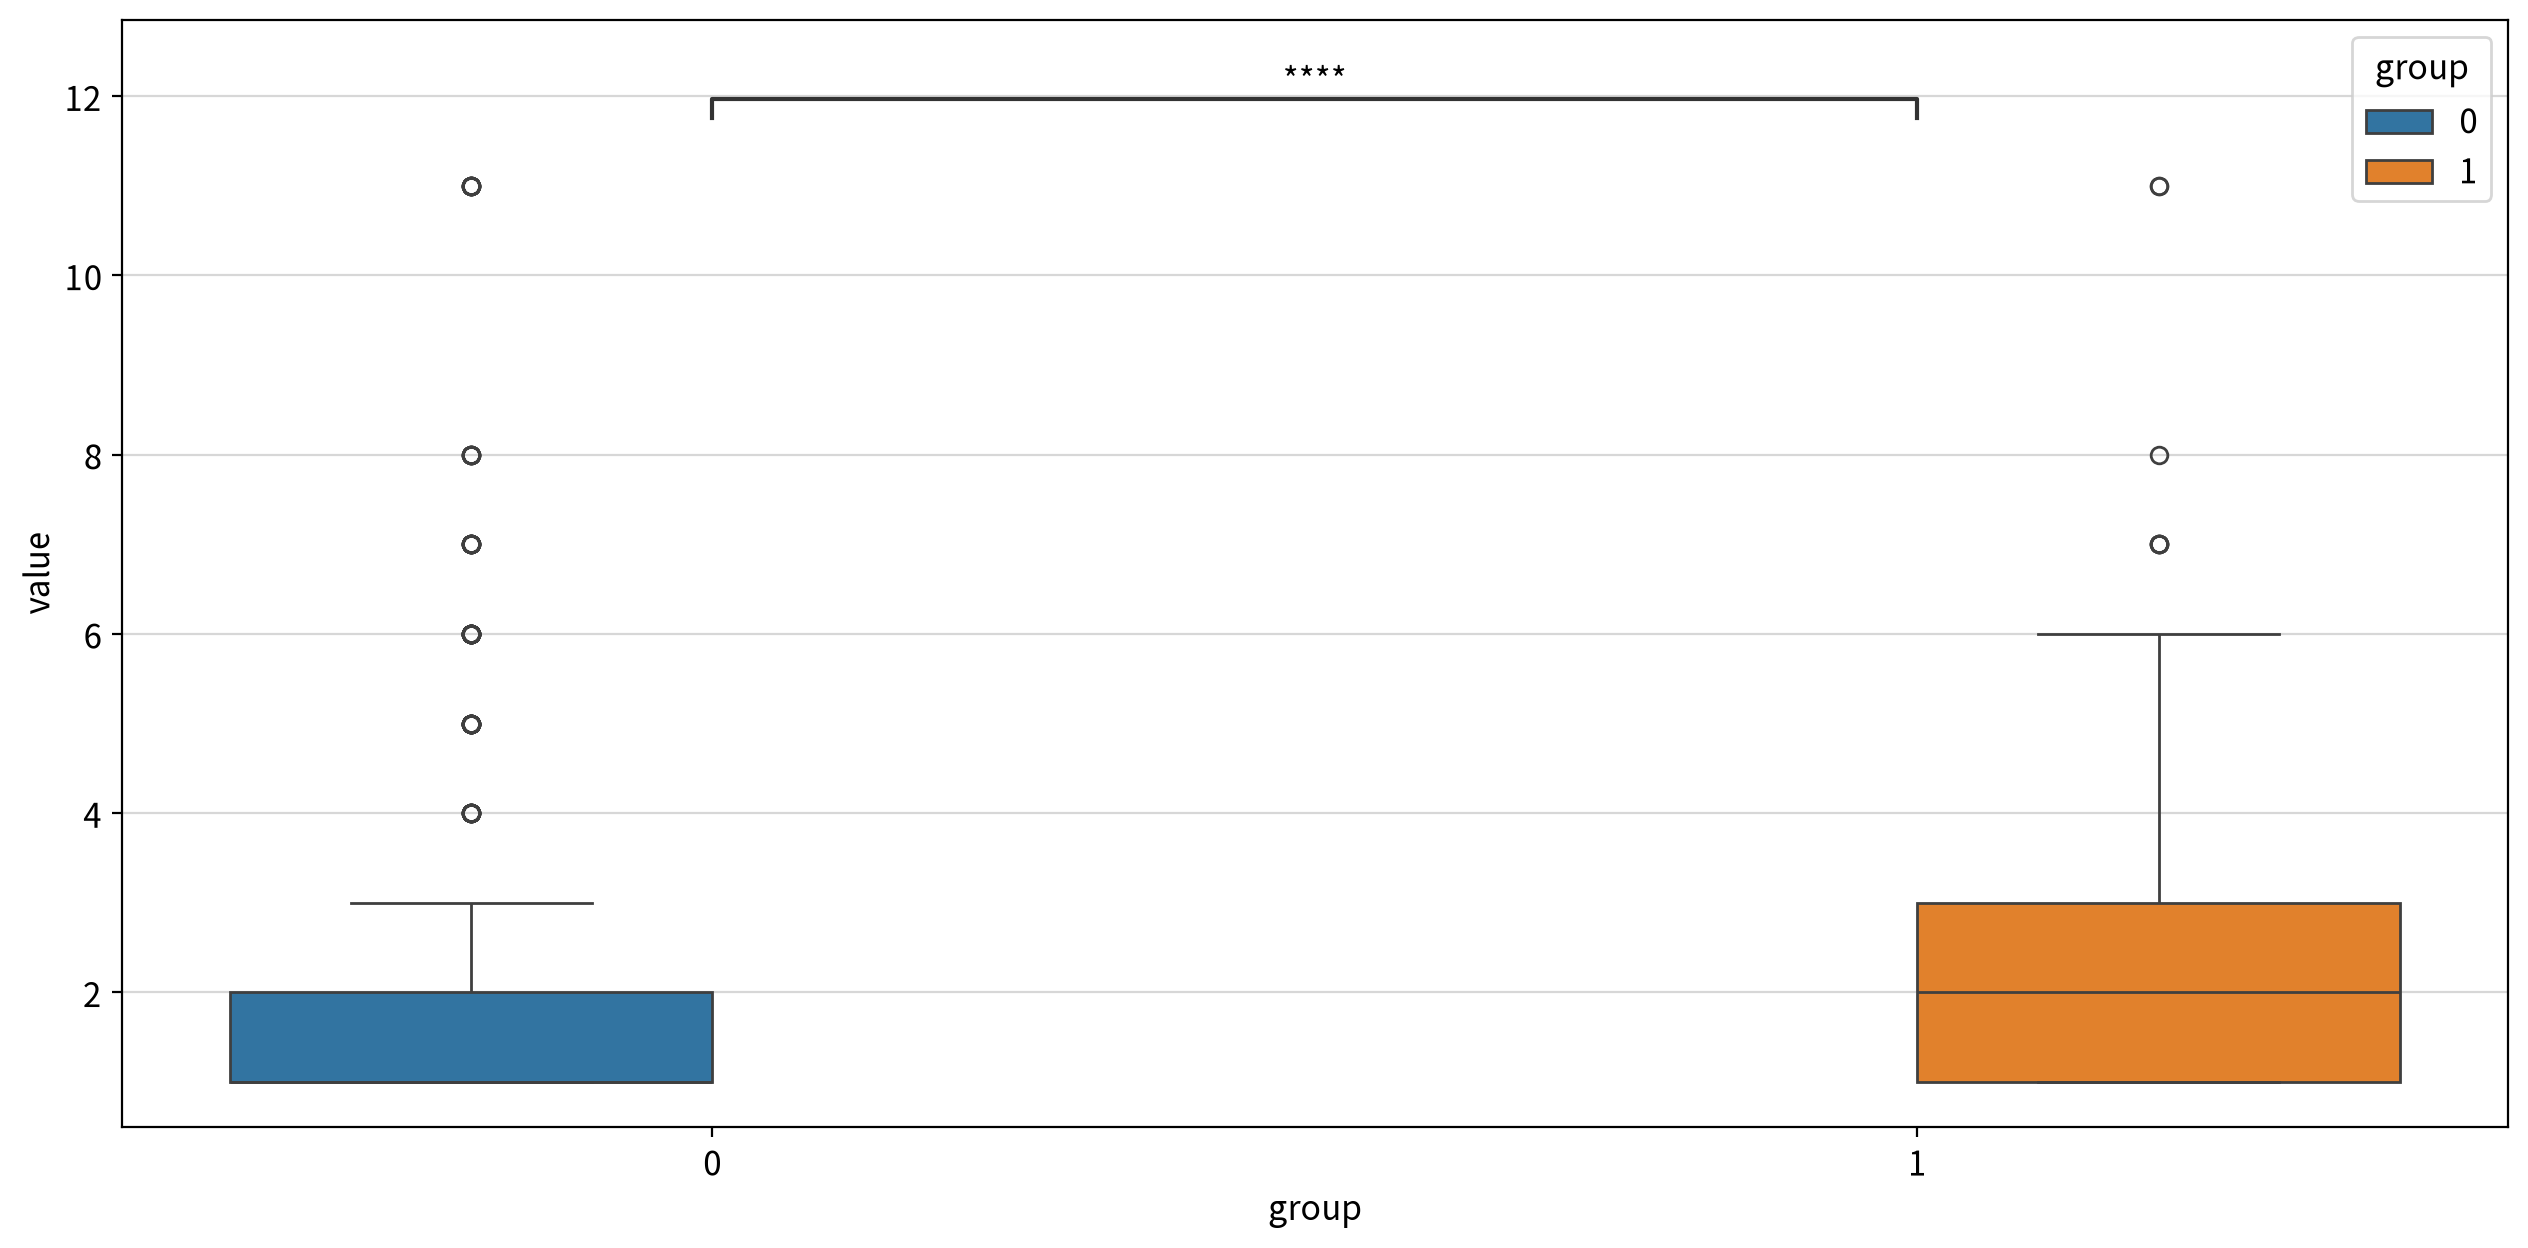

statistic  p-value  significant  result
test                alternative                                         
Mann-Whitney U test two-sided   160280.500    0.000         True  0 != 1
                    less        160280.500    0.000         True   0 < 1
                    greater     160280.500    1.000        False  0 <= 1

In [9]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### 📊 {f}({column_means[f]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # -> 선형회귀 때와 hue/values 가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df,
                                      group1=wide_df.columns[0], group2=wide_df.columns[1], plot=True))

### 2. FamilySize 범주별 분포

,사망률,생존률,인원수
FamilySize,,,
1,0.709,0.291,787
2,0.468,0.532,235
3,0.440,0.560,159
4,0.279,0.721,43
5,0.773,0.227,22
6,0.800,0.200,25
7,0.688,0.312,16
8,0.875,0.125,8
11,0.818,0.182,11


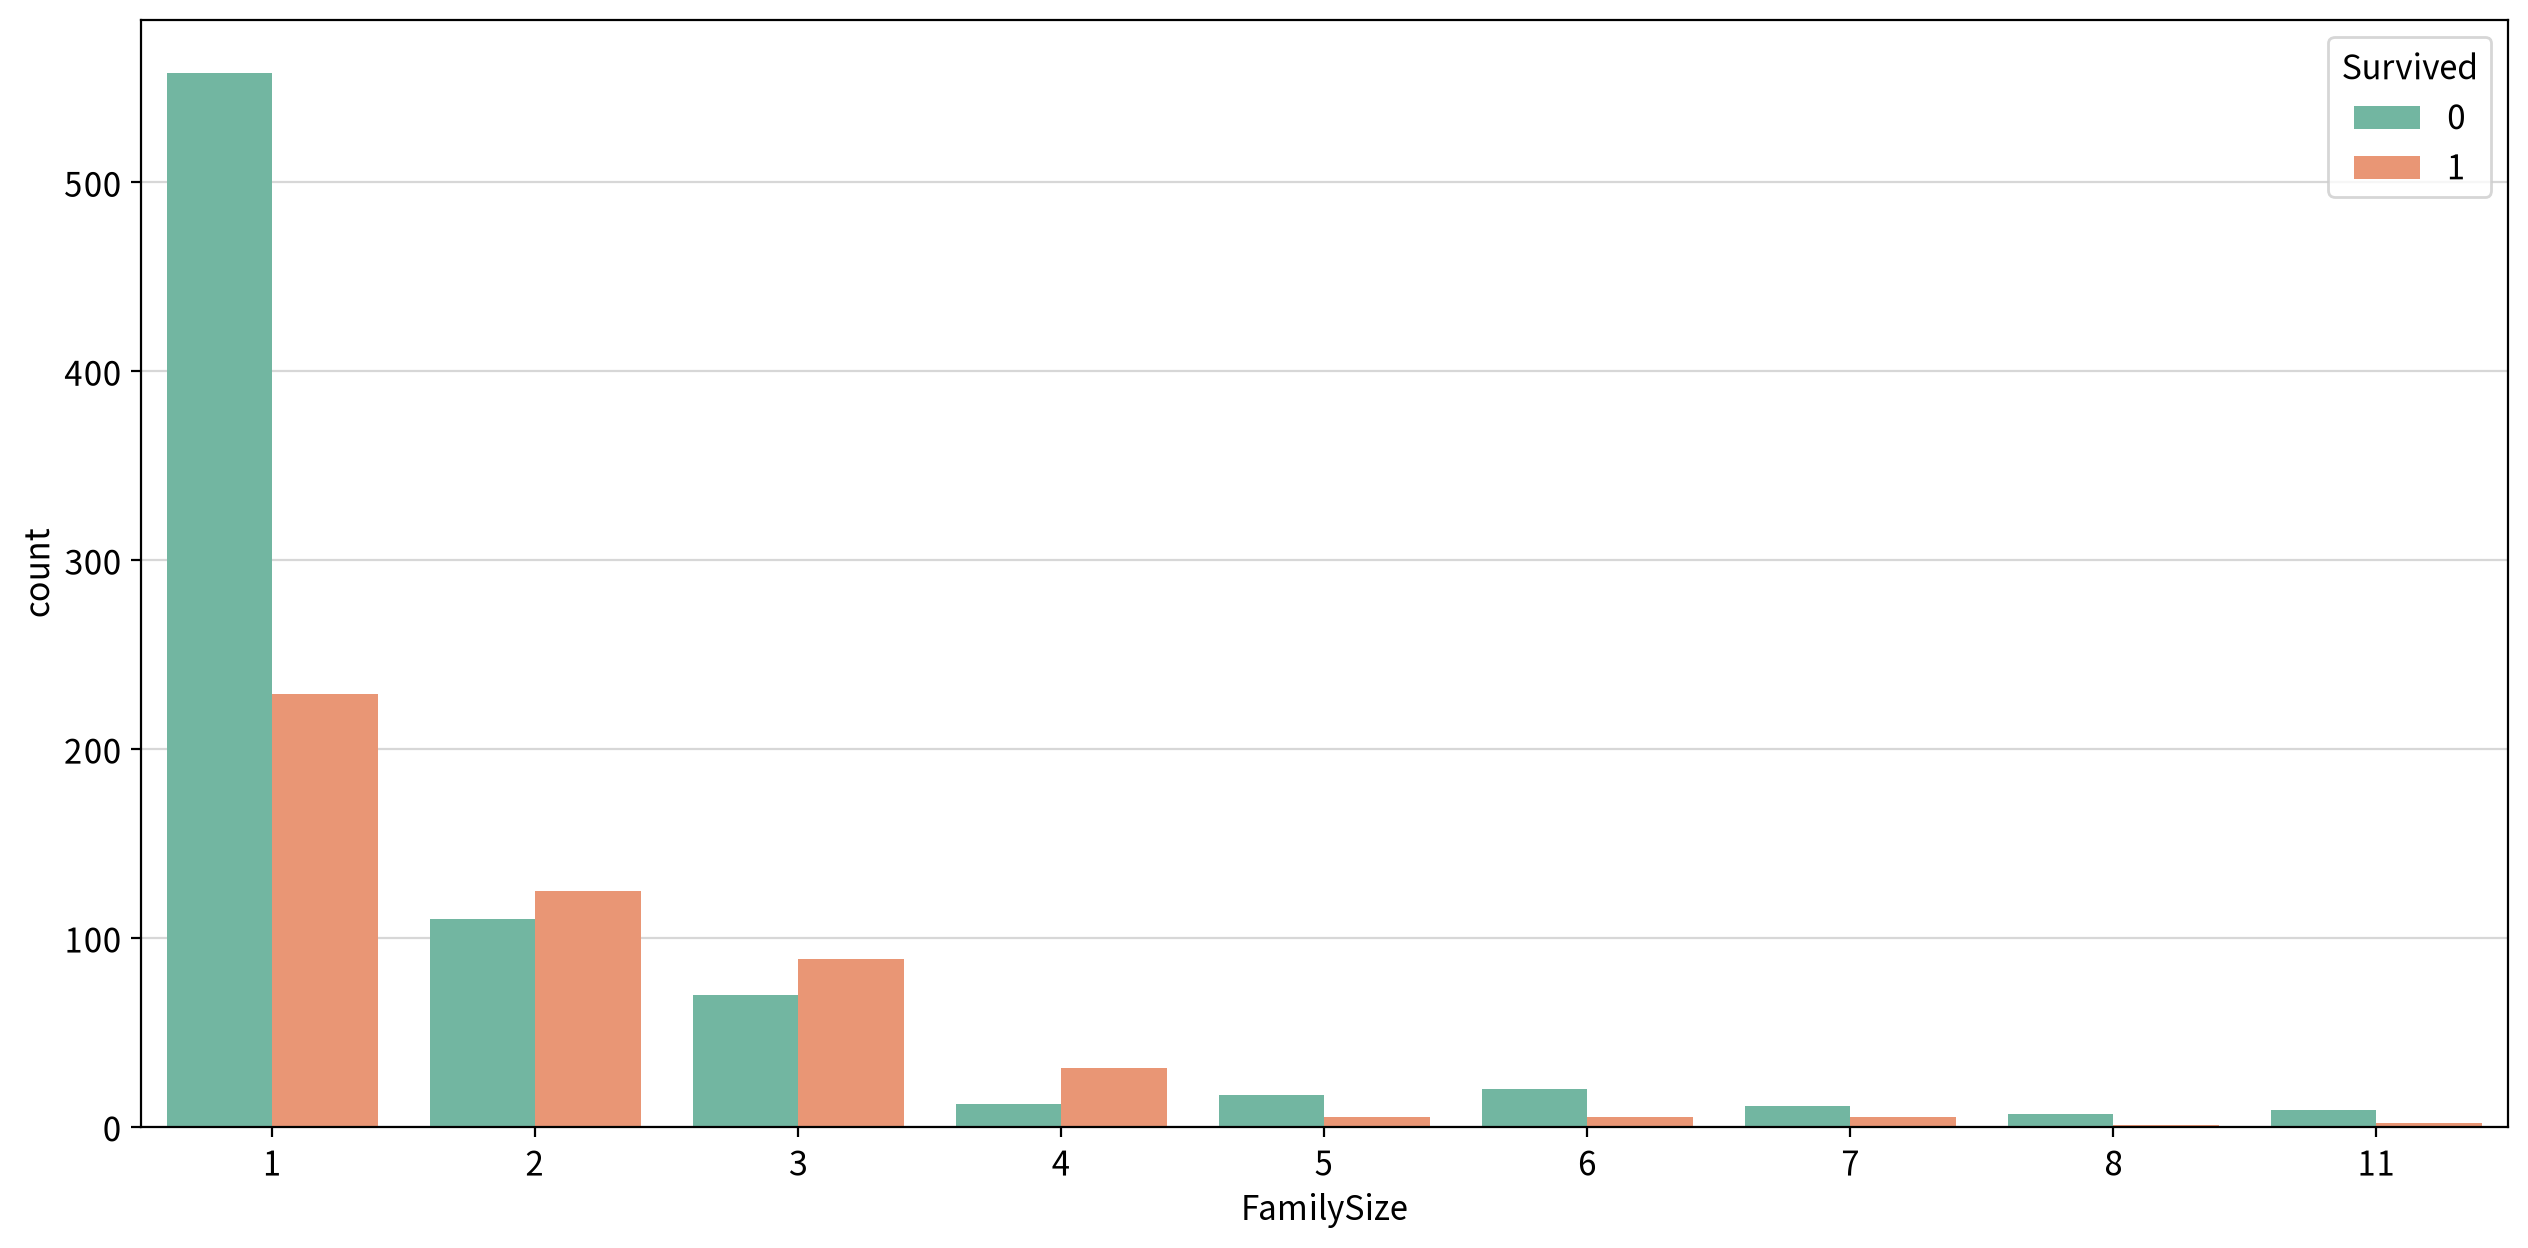

<Axes: xlabel='FamilySize', ylabel='count'>

In [10]:
# 가족 규모별 생존율을 직접 계산한다
fs_rate = df.groupby("FamilySize", observed=True) \
            [target].value_counts(normalize=True).unstack()
fs_rate.columns = ["사망률", "생존률"]
fs_rate["인원수"] = df["FamilySize"].value_counts().sort_index()
display(fs_rate)

# 시각화: 가족 규모별 생존 빈도
my_plot.countplot(data=df, x="FamilySize", hue=target, palette="Set2")

### 3. 교차분석(x: 명목형 독립변수 --> y:명목형 종속변수)

#### 📊 Pclass(객실 등급 (1=1등급, 2=2등급, 3=3등급)) → Survived

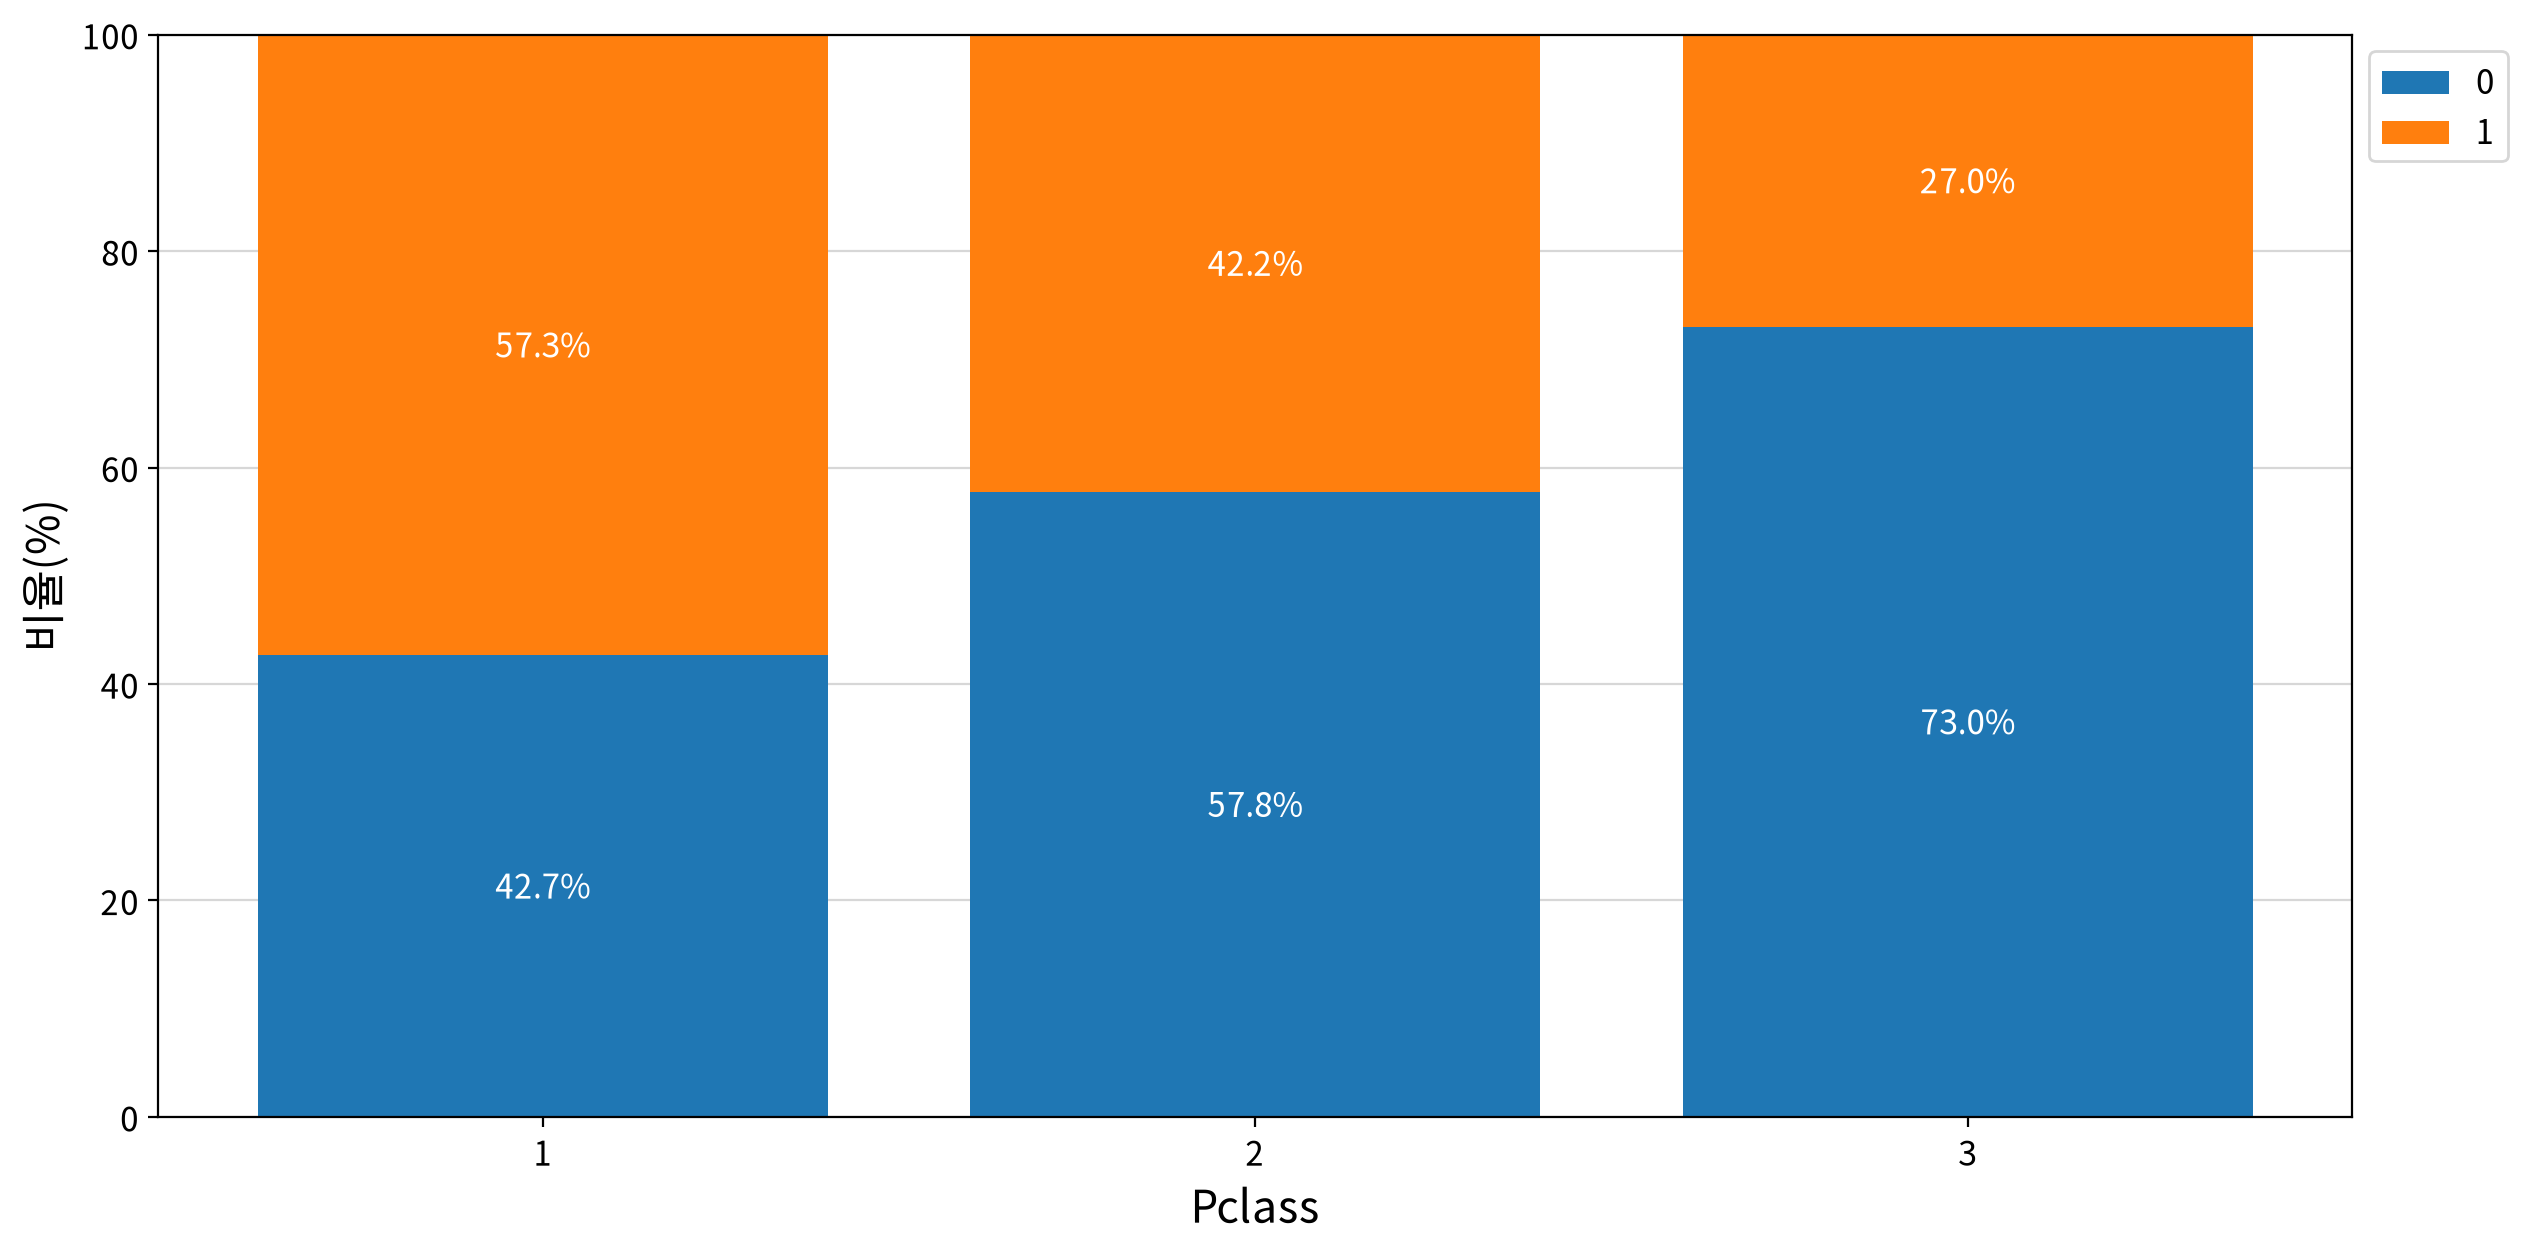

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Pclass,Survived,Chi-square test of independence,89.728,2,0.000,True,0.262,Weak,104.350,True


#### 📊 Embarked(탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)) → Survived

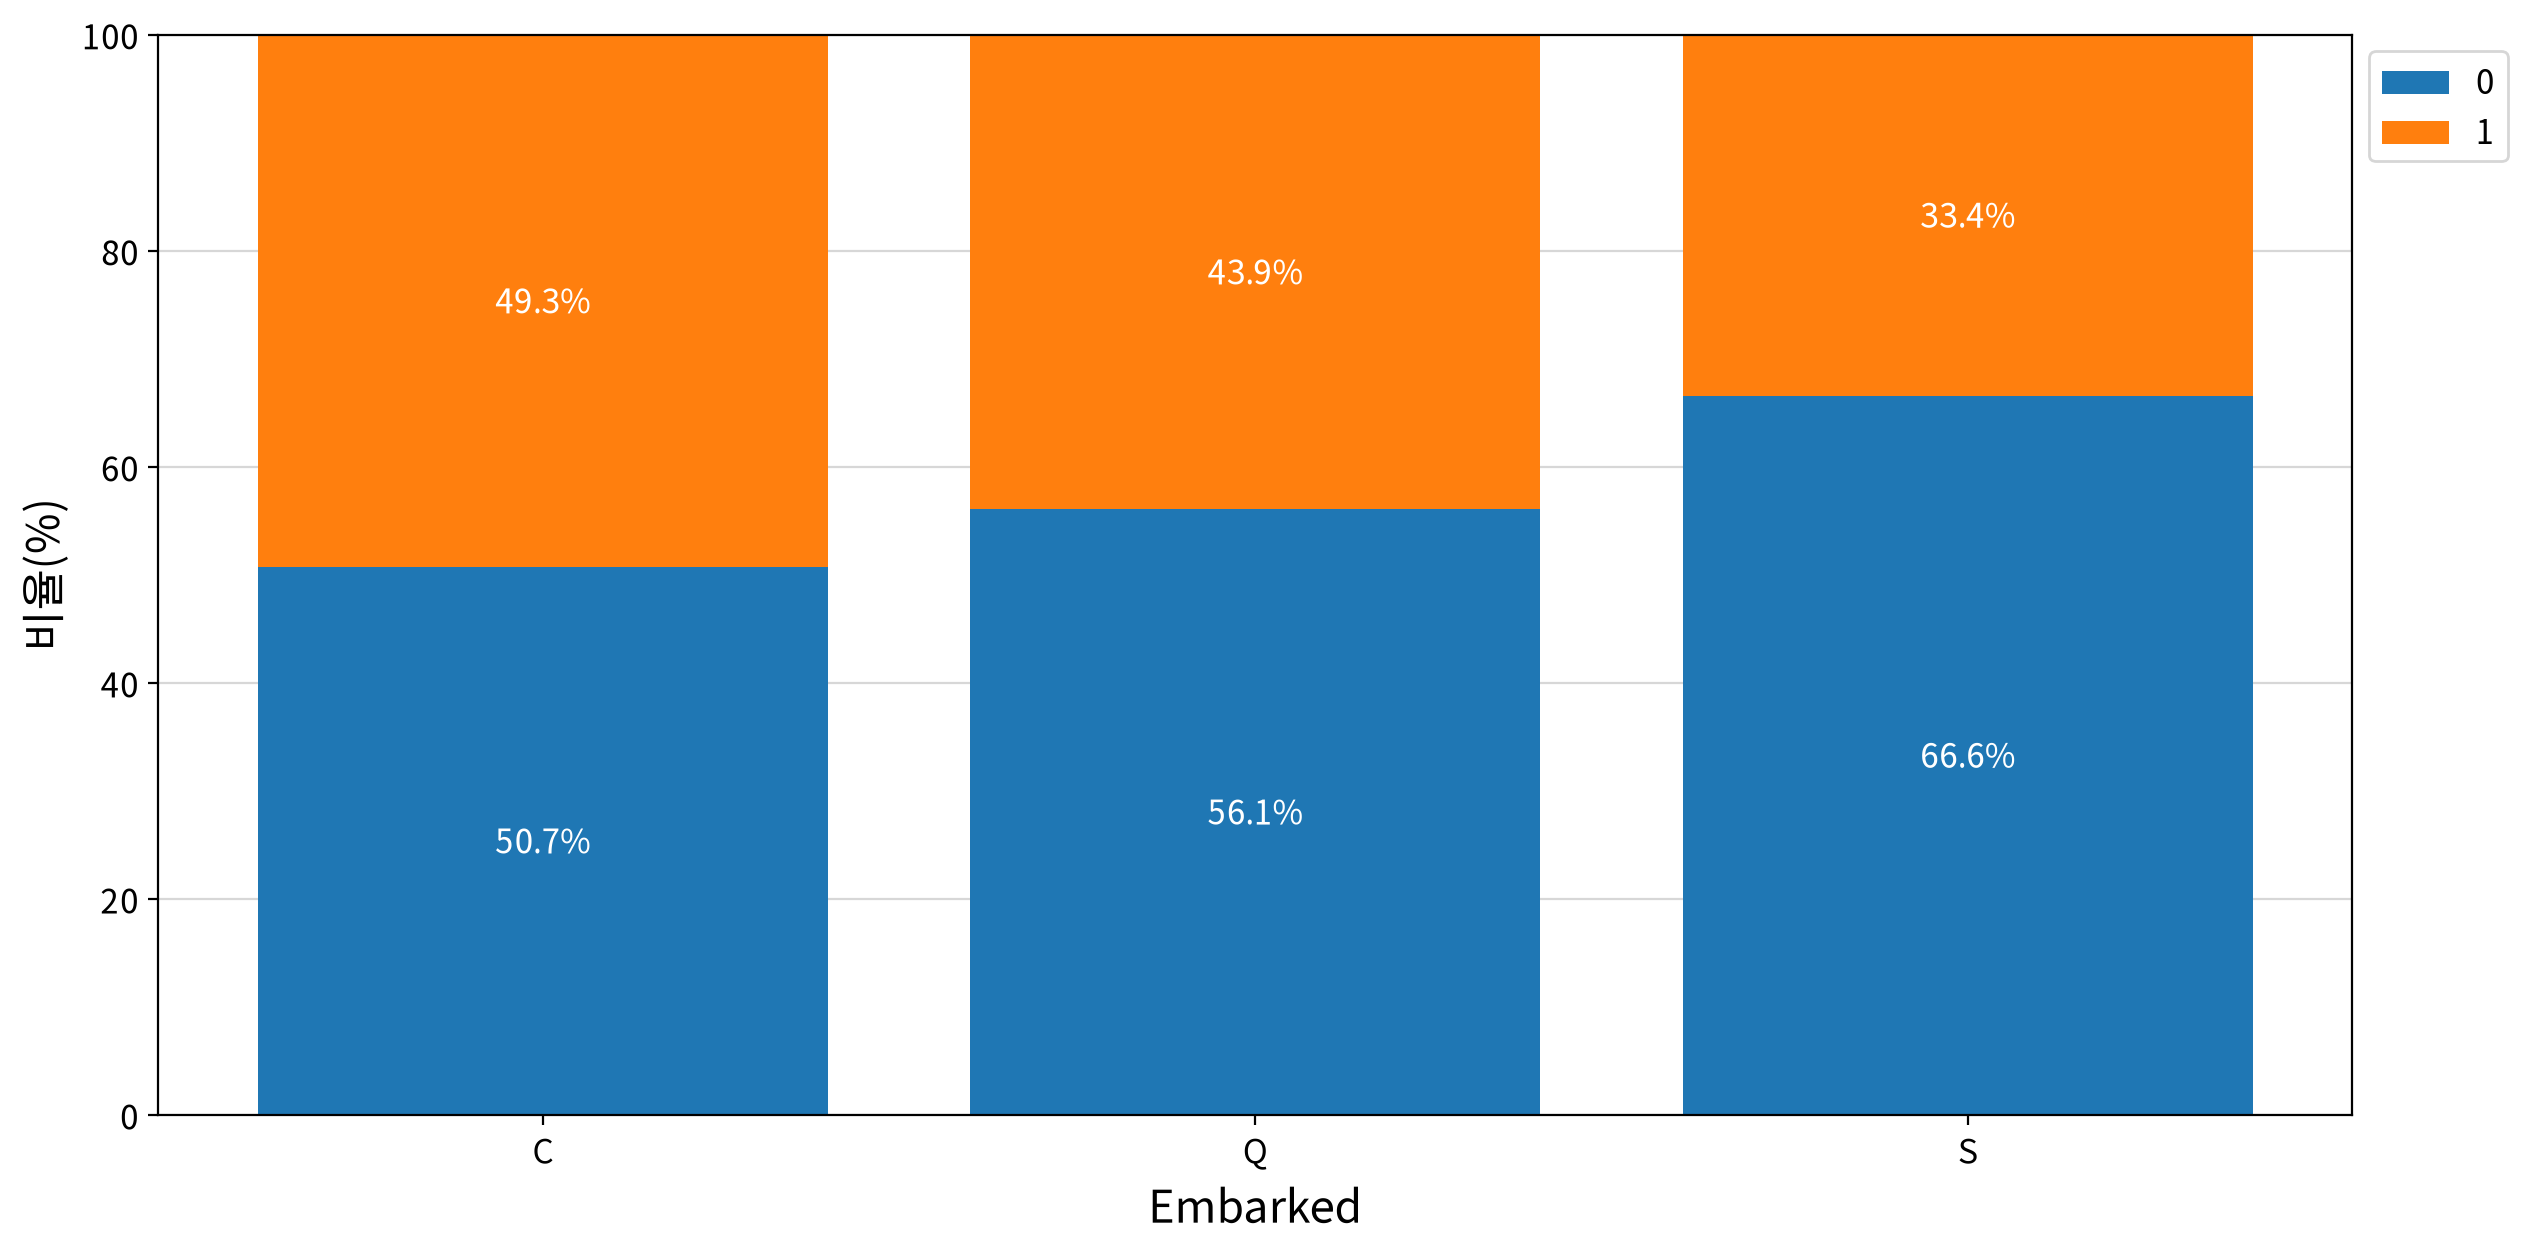

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Embarked,Survived,Chi-square test of independence,24.548,2,0.000,True,0.137,Weak,46.340,True


#### 📊 HasCabin(선실 존재 여부 (True=선실 있음, False=선실 없음)) → Survived

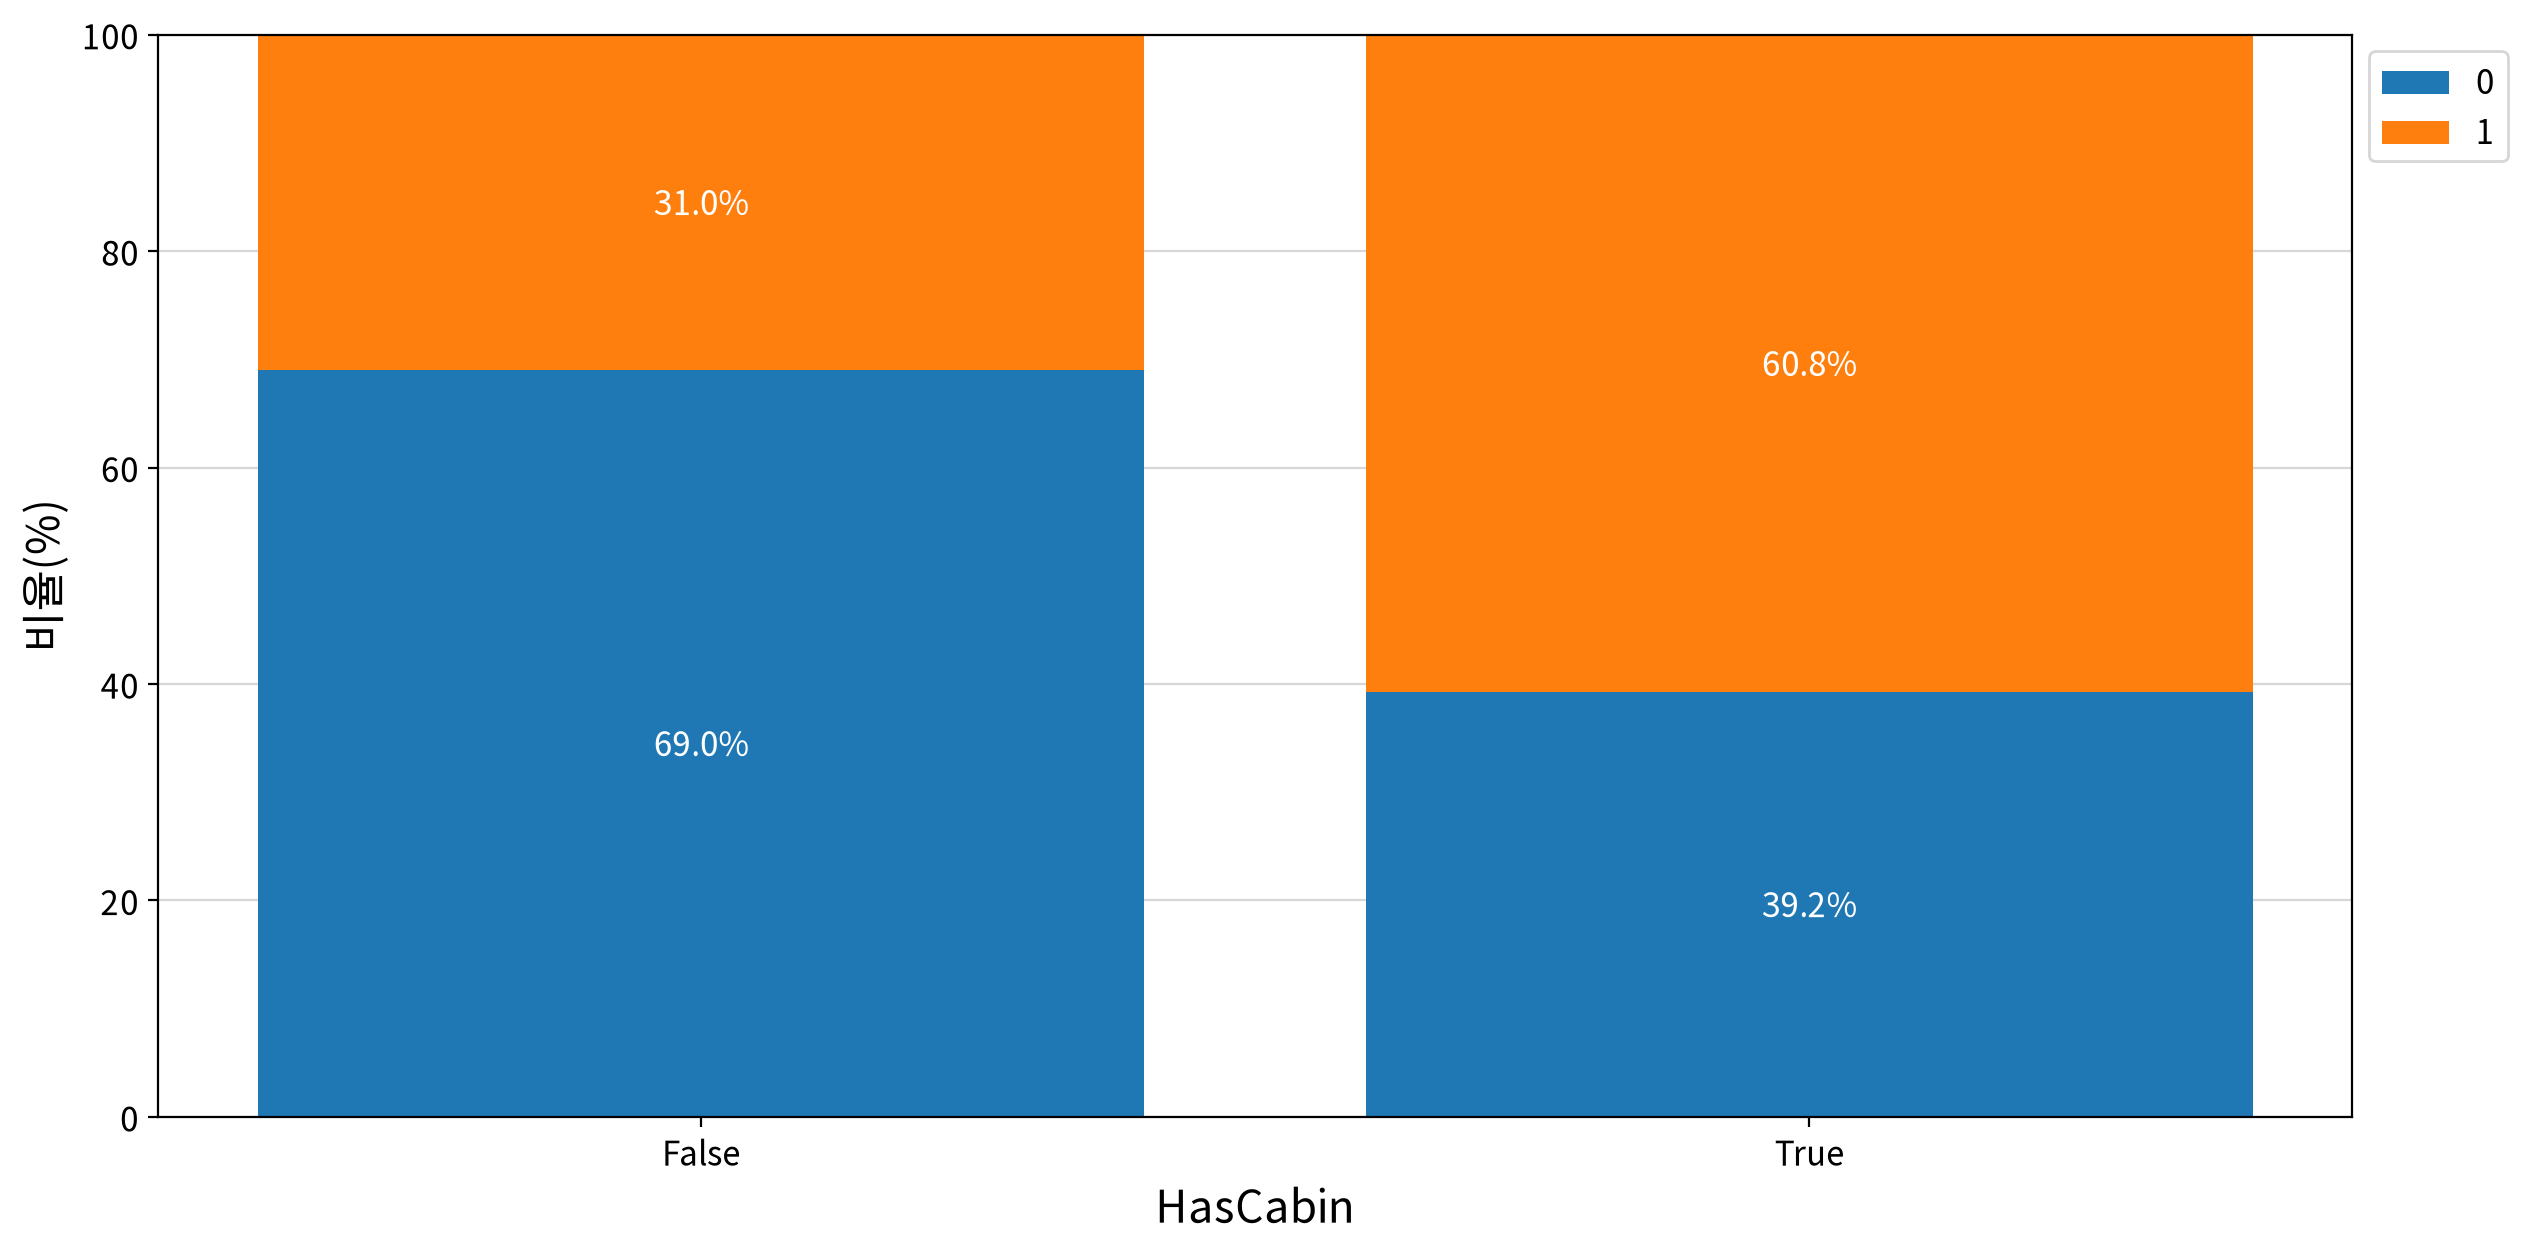

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
HasCabin,Survived,Chi-square test of independence,84.425,1,0.000,True,0.254,Weak,110.380,True


#### 📊 Title(이름에서 추출한 호칭 (Mr/Mrs/Miss/Master/Officer)) → Survived

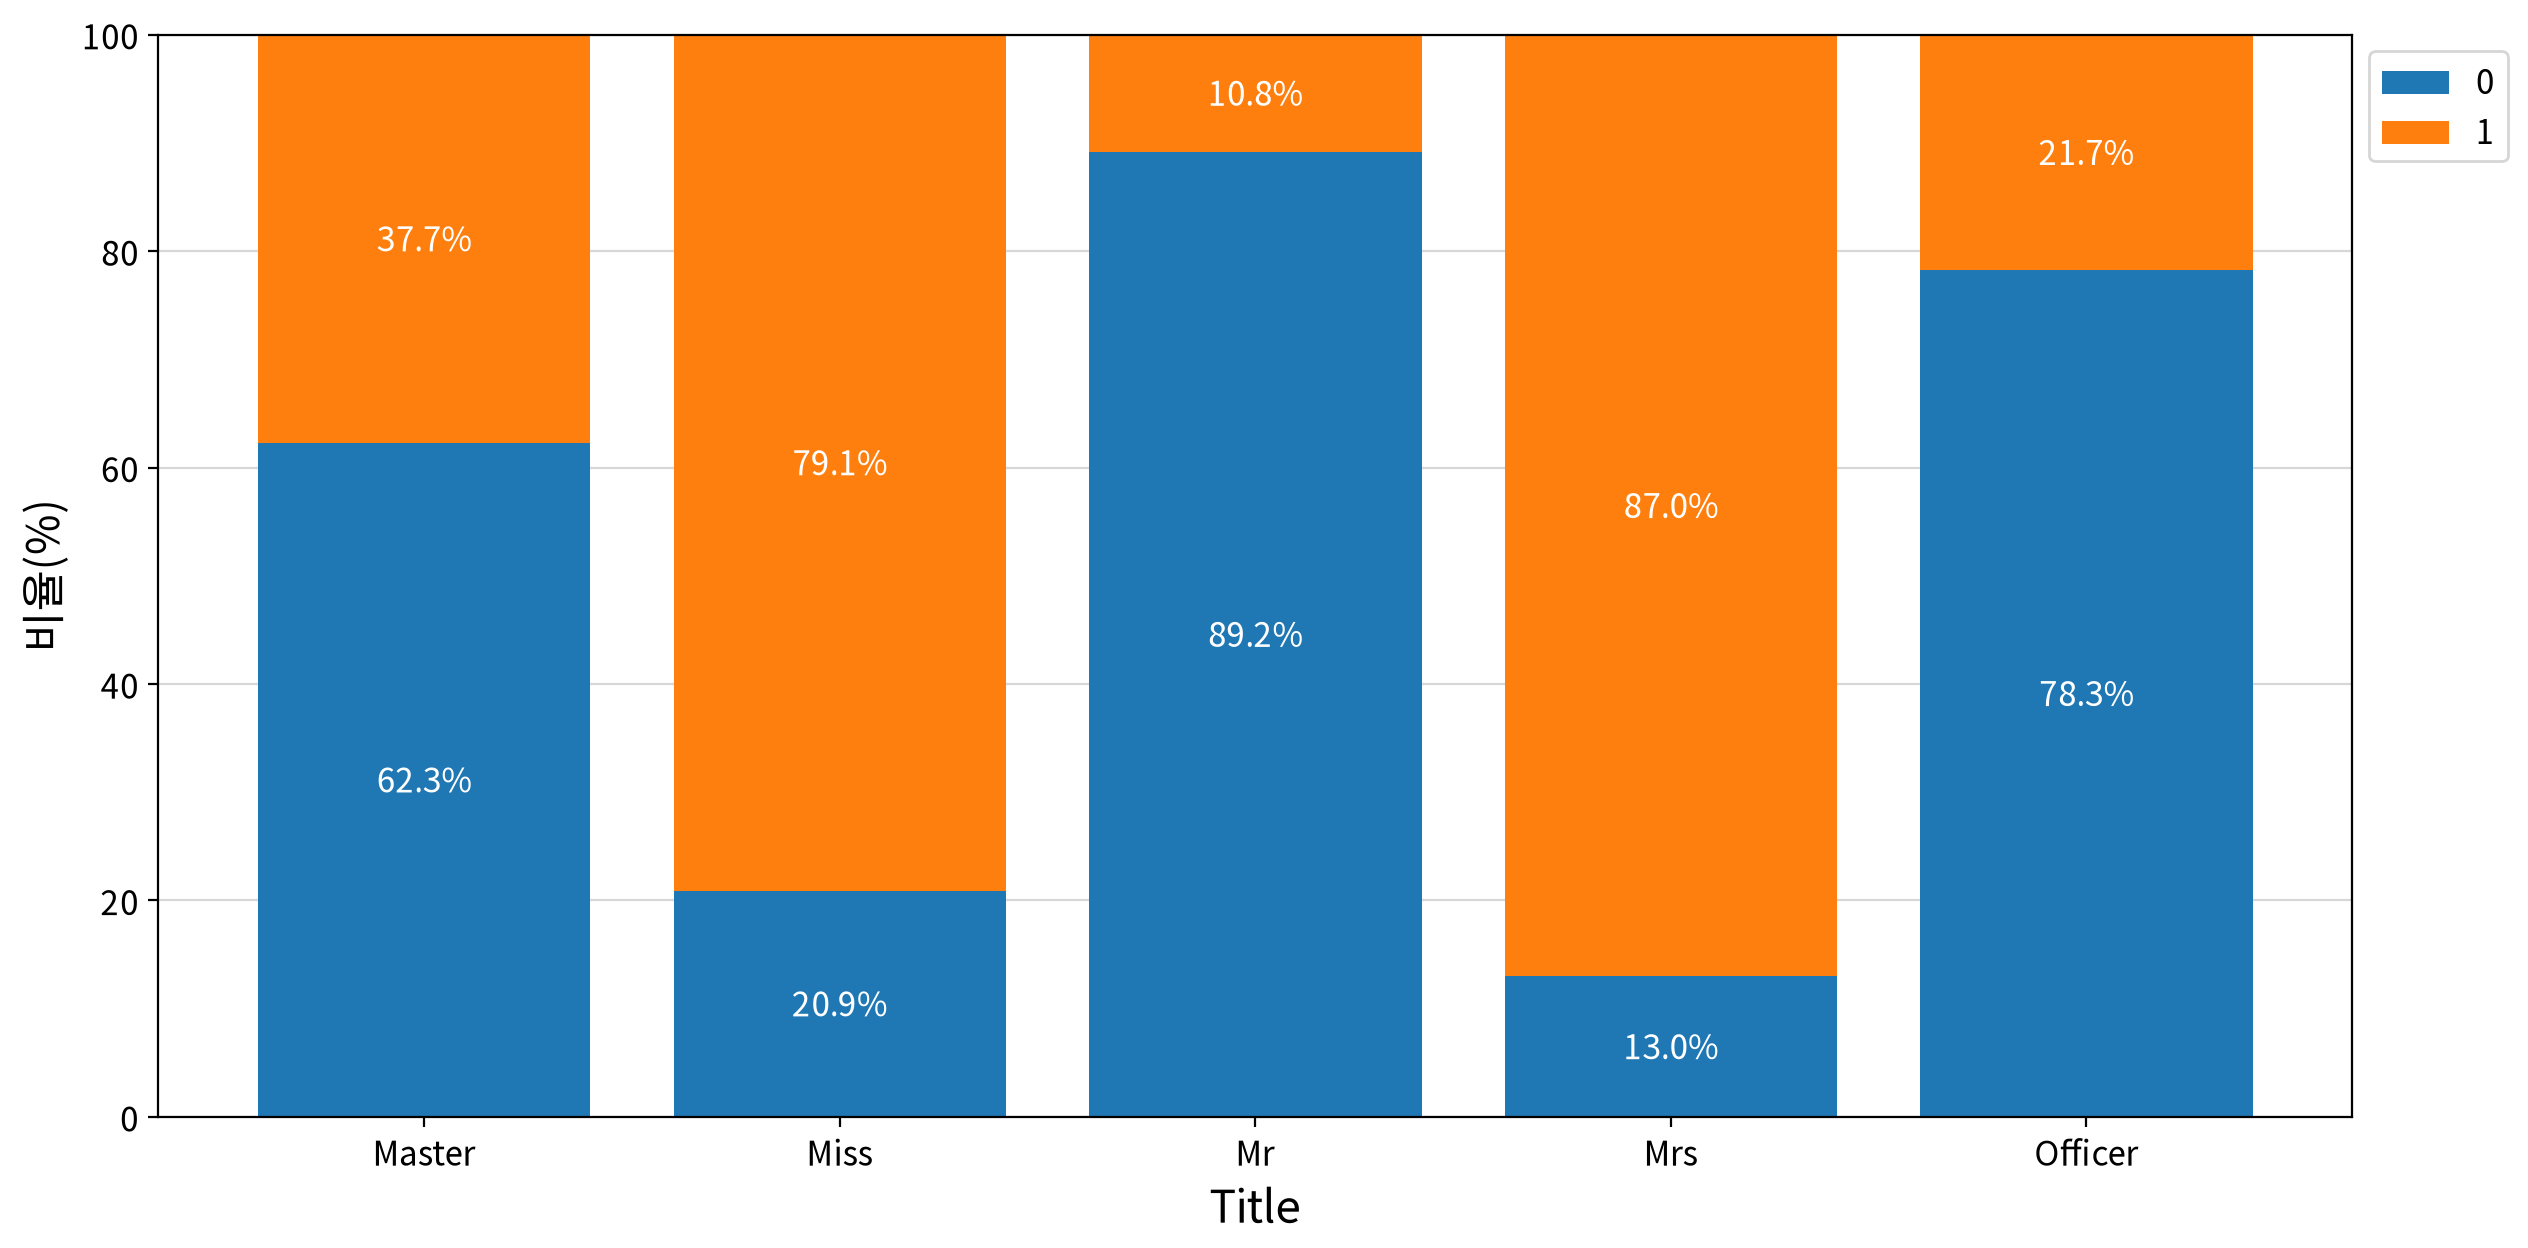

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
Title,Survived,Chi-square test of independence,635.224,4,0.000,True,0.697,Strong,8.660,True


In [11]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### 📊 {n}({column_means[n]}) → {target}"))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=True))

# 04. 다변량 분석

### 1. 독립변수간 상관 분석

In [12]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
display(my_stats.correlation_summary(corr))

# 분산팽창지수(VIF)로 한 번 더 확인
display(my_stats.compute_vif(df[continuous_cols]))

method   coef  p-value  strength  significant  normality_x  \
x    y                                                                          
Age  Fare        Spearman  0.178    0.000      Weak         True        False   
     FamilySize  Spearman -0.144    0.000      Weak         True        False   
Fare FamilySize  Spearman  0.524    0.000  Moderate         True        False   

                 normality_y  linearity  influential_outlier  high_skew  
x    y                                                                   
Age  Fare              False      False                False       True  
     FamilySize        False      False                 True       True  
Fare FamilySize        False      False                 True       True

,Age,Fare,FamilySize
Age,1.000,0.178,-0.144
Fare,0.178,1.000,0.524
FamilySize,-0.144,0.524,1.000


,max-y,max-coef,count,columns
x,,,,
FamilySize,Fare,0.524,0,-
Fare,FamilySize,0.524,0,-
Age,Fare,0.178,0,-


,VIF,Tolerance
Variable,,
FamilySize,1.132,0.884
Fare,1.118,0.894
Age,1.109,0.902


# #04. 최종 변수 선택

---

### 1. 변수별 판정

| 채택여부 | 변수 | 검정방법 | 유의확률 | 방향 | 공선성 신호 | 근거 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| ✅ **채택** | **Title** | 교차분석 | < 0.001 | Mrs > Miss > Master > Officer > Mr | — | V = 0.697 (**Strong**) — 이 데이터 최고 |
| ✅ **채택** | Pclass | 교차분석 | < 0.001 | 1등급 > 2등급 > 3등급 | — | V = 0.262 (Weak) — 등급 순서대로 단조 감소 |
| ✅ **채택** | HasCabin | 교차분석 | < 0.001 | 있음 > 없음 | 있음의 86.7%가 1등급 | V = 0.254 (Weak) — Pclass 의 대리 지표 가능성 |
| ✅ **채택** | Embarked | 교차분석 | < 0.001 | C > Q > S | 항구별 Pclass 구성 차이 | V = 0.137 (Weak) — 유의하나 Pclass 와 겹칠 가능성 |
| ✅ **채택** | Fare | Mann-Whitney U | < 0.001 | 생존 > 사망 | X (VIF 1.12 · FamilySize 와 ρ 0.52) | 평균 2배 · 중앙값 2.5배 차이 |
| ✅ **채택** | FamilySize | Mann-Whitney U | < 0.001 | 생존 > 사망 (역U자) | X (VIF 1.13) | 순위 분포 차이 유의 — 4명까지 상승 후 급락 |
| 🟡 **보류** | Age | Mann-Whitney U | 0.116 | — | X (VIF 1.11) | 단독 차이는 없으나 **억제효과 가능성** → 투입 후 계수로 판정 |

* **연속형 3종 사이의 공선성은 없다.** 상관계수(정규성 미충족으로 Spearman)는 최대 0.524( Fare – FamilySize )로 Strong 기준 0.7 미만이고, VIF는 세 변수 모두 1.1 수준이다.

* **명목형끼리의 겹침은 교차표로만 확인했으므로 정량 판정이 아니다.** HasCabin · Embarked 가 Pclass 와 얼마나 겹치는지는 모형에 함께 넣었을 때 계수와 표준오차의 변화로 판정한다.

* **이 데이터셋은 품질점검 단계에서 이미 정리된 버전이다.** PassengerId · Ticket (식별자), Name (→ Title 추출), Cabin (→ HasCabin 변환), SibSp · Parch (→ FamilySize 합산), Sex (성별 정보는 Title 에 포함)는 제거되어 포함되지 않는다.

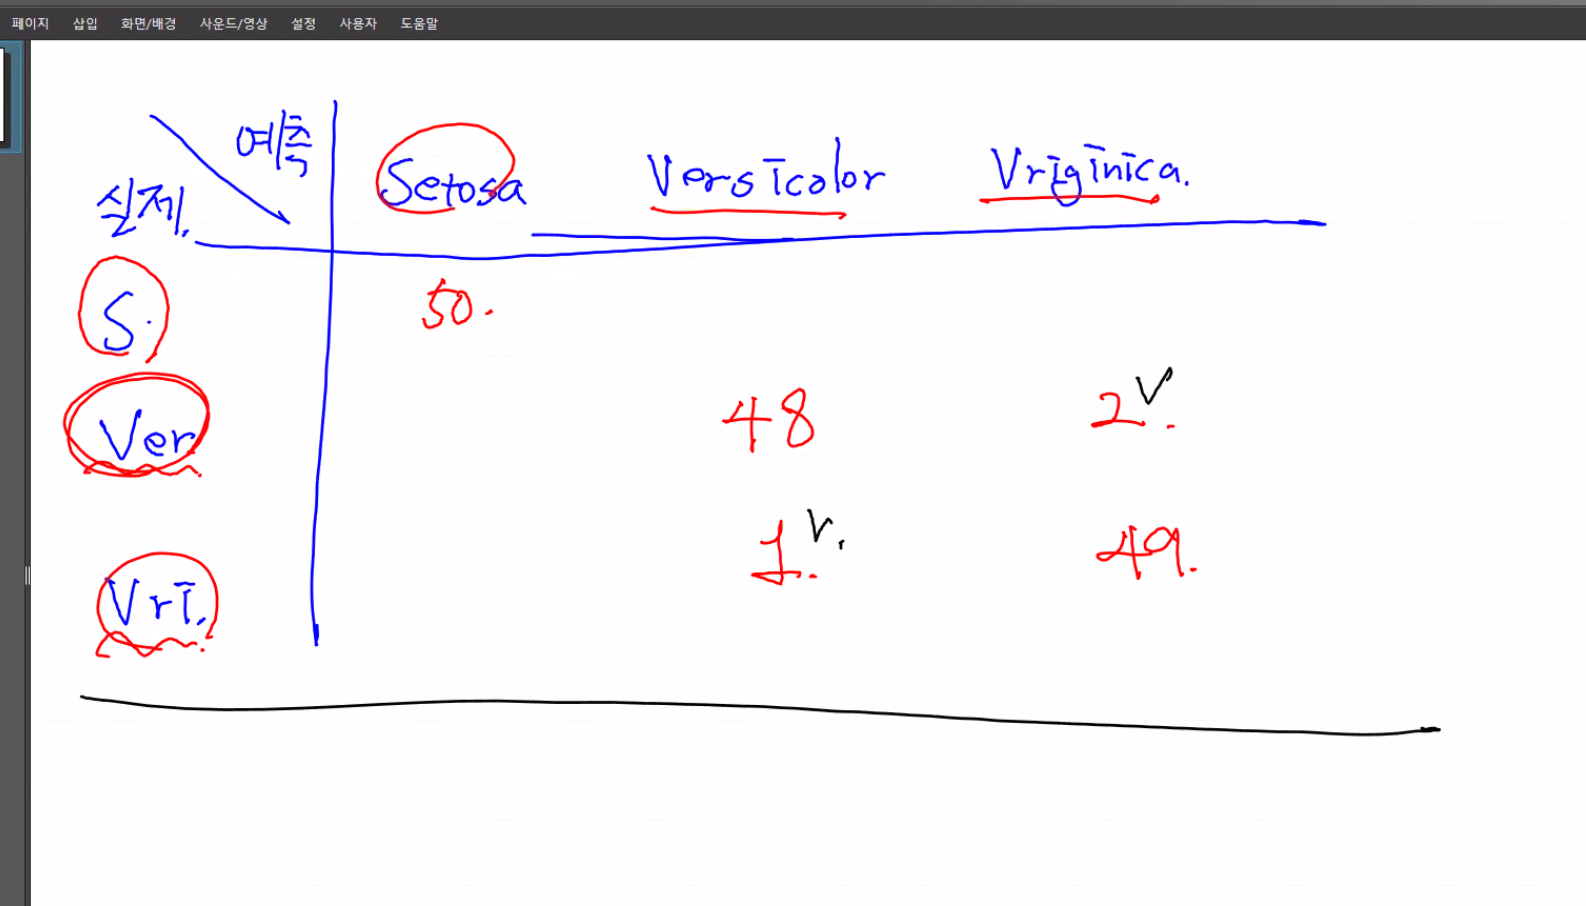

### 最基础的二分类： 

|                     | Predicted Positive | Predicted Negative |
| ------------------- | -----------------: | -----------------: |
| **Actual Positive** |                 TP |                 FN |
| **Actual Negative** |                 FP |                 TN |

### 四个概念非常重要：

TP (True Positive)：实际是正类，预测也是正类   
TN (True Negative)：实际是负类，预测也是负类   
FP (False Positive)：实际是负类，却预测成正类   
FN (False Negative)：实际是正类，却预测成负类   

### 比如信用违约预测：   
|          |   预测违约 |   预测正常 |
| -------- | -----: | -----: |
| **实际违约** |     TP | **FN** |
| **实际正常** | **FP** |     TN |

### FN 特别值得关注：这个人实际上会违约，但模型却说“不会违约”

### 3分类（multiclass classification：3×3 confusion matrix   

| Actual ↓ / Predicted → | Setosa | Versicolor | Virginica |
| ---------------------- | -----: | ---------: | --------: |
| Setosa                 |     50 |          0 |         0 |
| Versicolor             |      0 |         48 |         2 |
| Virginica              |      0 |          1 |        49 |

### 对角线代表预测正确, 非对角线代表预测错误